# News Recommendation System Project Comp9727

**Nama**: PanHang\
**zID**: z5598515\
**Email**: z5598515@ad.unsw.edu.au

Three news recommendation systems were constructed and evaluated, using the dataset MIND. The adopted methods include content-based filtering (using TF-IDF/ Bert /sBert/tfidf+sBert), collaborative filtering (based on the embedding model of pytorch) and the hybird model of CB+CF. The evaluation method is Recall@K, The proportion of the number of news items actually clicked by users to the total number of news items actually clicked by users.

# 1. Load Data

In [1]:
import os
import ast
from collections import defaultdict
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity, linear_kernel
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from scipy.sparse import csr_matrix

import tensorflow as tf
from tensorflow.keras import layers

pd.set_option('display.max_columns', None)

2025-08-05 23:13:27.415319: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
!pip install sentence-transformers # to load sbert

In [3]:
import warnings

warnings.filterwarnings("ignore", category=RuntimeWarning)

In [4]:
import random
import numpy as np
import tensorflow as tf
import os

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

set_seed()

In [5]:
behaviors = pd.read_csv('./kaggle/input/mind-news-dataset/MINDsmall_train/behaviors.tsv', sep='\t', 
                        names=["Impression_ID", "User_ID", "Time", "History", "Impressions"])

news = pd.read_csv('./kaggle/input/mind-news-dataset/MINDsmall_train/news.tsv', sep='\t',
                   names=["News_ID", "Category", "SubCategory", "Title", "Abstract", "URL", "Title_Entities", "Abstract_Entities"])


ray - coldstart study.

In [6]:
import pandas as pd

# set your limit
N = 7  # keep at most N items

def pop_front_until_n(history_str, n):
    if pd.isna(history_str):
        return history_str
    items = history_str.strip().split()
    while len(items) > n:
        items.pop(0)  # pop from the front
    return ' '.join(items)

# permanently modify the "History" column in-place
behaviors['History'] = behaviors['History'].apply(lambda s: pop_front_until_n(s, N))

In [7]:
behaviors.head()

,Impression_ID,User_ID,Time,History,Impressions
0,1,U13740,11/11/2019 9:05:58 AM,N34694 N45794 N18445 N63302 N10414 N19347 N31801,N55689-1 N35729-0
1,2,U91836,11/12/2019 6:11:30 PM,N35458 N24611 N37509 N21773 N41011 N19041 N25785,N20678-0 N39317-0 N58114-0 N20495-0 N42977-0 N...
2,3,U73700,11/14/2019 7:01:48 AM,N33164 N47289 N24233 N62058 N26378 N49475 N18870,N50014-0 N23877-0 N35389-0 N49712-0 N16844-0 N...
3,4,U34670,11/11/2019 5:28:05 AM,N53880 N41375 N43142 N33013 N29757 N31825 N51891,N35729-0 N33632-0 N49685-1 N27581-0
4,5,U8125,11/12/2019 4:11:21 PM,N10078 N56514 N14904 N33740,N39985-0 N36050-0 N16096-0 N8400-1 N22407-0 N6...


In [8]:
news.info(),news.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51282 entries, 0 to 51281
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   News_ID            51282 non-null  object
 1   Category           51282 non-null  object
 2   SubCategory        51282 non-null  object
 3   Title              51282 non-null  object
 4   Abstract           48616 non-null  object
 5   URL                51282 non-null  object
 6   Title_Entities     51279 non-null  object
 7   Abstract_Entities  51278 non-null  object
dtypes: object(8)
memory usage: 3.1+ MB


(None, (51282, 8))

# 2. Data Preprocessing

In [28]:
news.head()

,News_ID,Category,SubCategory,Title,Abstract,URL,Title_Entities,Abstract_Entities
0,N55528,lifestyle,lifestyleroyals,"The Brands Queen Elizabeth, Prince Charles, an...","Shop the notebooks, jackets, and more that the...",https://assets.msn.com/labs/mind/AAGH0ET.html,"[{""Label"": ""Prince Philip, Duke of Edinburgh"",...",[]
1,N19639,health,weightloss,50 Worst Habits For Belly Fat,These seemingly harmless habits are holding yo...,https://assets.msn.com/labs/mind/AAB19MK.html,"[{""Label"": ""Adipose tissue"", ""Type"": ""C"", ""Wik...","[{""Label"": ""Adipose tissue"", ""Type"": ""C"", ""Wik..."
2,N61837,news,newsworld,The Cost of Trump's Aid Freeze in the Trenches...,Lt. Ivan Molchanets peeked over a parapet of s...,https://assets.msn.com/labs/mind/AAJgNsz.html,[],"[{""Label"": ""Ukraine"", ""Type"": ""G"", ""WikidataId..."
3,N53526,health,voices,I Was An NBA Wife. Here's How It Affected My M...,"I felt like I was a fraud, and being an NBA wi...",https://assets.msn.com/labs/mind/AACk2N6.html,[],"[{""Label"": ""National Basketball Association"", ..."
4,N38324,health,medical,"How to Get Rid of Skin Tags, According to a De...","They seem harmless, but there's a very good re...",https://assets.msn.com/labs/mind/AAAKEkt.html,"[{""Label"": ""Skin tag"", ""Type"": ""C"", ""WikidataI...","[{""Label"": ""Skin tag"", ""Type"": ""C"", ""WikidataI..."


In [29]:
behaviors.head()

,Impression_ID,User_ID,Time,History,Impressions,Impressions_parsed,History_parsed
0,1,U13740,11/11/2019 9:05:58 AM,N34694 N45794 N18445 N63302 N10414 N19347 N31801,N55689-1 N35729-0,"[(N55689, 1), (N35729, 0)]","[N34694, N45794, N18445, N63302, N10414, N1934..."
1,2,U91836,11/12/2019 6:11:30 PM,N35458 N24611 N37509 N21773 N41011 N19041 N25785,N20678-0 N39317-0 N58114-0 N20495-0 N42977-0 N...,"[(N20678, 0), (N39317, 0), (N58114, 0), (N2049...","[N35458, N24611, N37509, N21773, N41011, N1904..."
2,3,U73700,11/14/2019 7:01:48 AM,N33164 N47289 N24233 N62058 N26378 N49475 N18870,N50014-0 N23877-0 N35389-0 N49712-0 N16844-0 N...,"[(N50014, 0), (N23877, 0), (N35389, 0), (N4971...","[N33164, N47289, N24233, N62058, N26378, N4947..."
3,4,U34670,11/11/2019 5:28:05 AM,N53880 N41375 N43142 N33013 N29757 N31825 N51891,N35729-0 N33632-0 N49685-1 N27581-0,"[(N35729, 0), (N33632, 0), (N49685, 1), (N2758...","[N53880, N41375, N43142, N33013, N29757, N3182..."
4,5,U8125,11/12/2019 4:11:21 PM,N10078 N56514 N14904 N33740,N39985-0 N36050-0 N16096-0 N8400-1 N22407-0 N6...,"[(N39985, 0), (N36050, 0), (N16096, 0), (N8400...","[N10078, N56514, N14904, N33740]"


### 2.1. Data Cleaning

In [30]:
def parse_impressions(imp_str):
    if pd.isna(imp_str):
        return []
    items = imp_str.strip().split(' ')
    return [(i.split('-')[0], int(i.split('-')[1])) for i in items]

behaviors['Impressions_parsed'] = behaviors['Impressions'].apply(parse_impressions)


In [31]:
def parse_history(history_str):
    if pd.isna(history_str):
        return []
    return history_str.strip().split(' ')

behaviors['History_parsed'] = behaviors['History'].apply(parse_history)


In [32]:
behaviors

,Impression_ID,User_ID,Time,History,Impressions,Impressions_parsed,History_parsed
0,1,U13740,11/11/2019 9:05:58 AM,N34694 N45794 N18445 N63302 N10414 N19347 N31801,N55689-1 N35729-0,"[(N55689, 1), (N35729, 0)]","[N34694, N45794, N18445, N63302, N10414, N1934..."
1,2,U91836,11/12/2019 6:11:30 PM,N35458 N24611 N37509 N21773 N41011 N19041 N25785,N20678-0 N39317-0 N58114-0 N20495-0 N42977-0 N...,"[(N20678, 0), (N39317, 0), (N58114, 0), (N2049...","[N35458, N24611, N37509, N21773, N41011, N1904..."
2,3,U73700,11/14/2019 7:01:48 AM,N33164 N47289 N24233 N62058 N26378 N49475 N18870,N50014-0 N23877-0 N35389-0 N49712-0 N16844-0 N...,"[(N50014, 0), (N23877, 0), (N35389, 0), (N4971...","[N33164, N47289, N24233, N62058, N26378, N4947..."
3,4,U34670,11/11/2019 5:28:05 AM,N53880 N41375 N43142 N33013 N29757 N31825 N51891,N35729-0 N33632-0 N49685-1 N27581-0,"[(N35729, 0), (N33632, 0), (N49685, 1), (N2758...","[N53880, N41375, N43142, N33013, N29757, N3182..."
4,5,U8125,11/12/2019 4:11:21 PM,N10078 N56514 N14904 N33740,N39985-0 N36050-0 N16096-0 N8400-1 N22407-0 N6...,"[(N39985, 0), (N36050, 0), (N16096, 0), (N8400...","[N10078, N56514, N14904, N33740]"
...,...,...,...,...,...,...,...
156960,156961,U21593,11/14/2019 10:24:05 PM,N46473 N4607 N62957 N8148 N38783 N24803 N48925,N2235-0 N22975-0 N64037-0 N47652-0 N11378-0 N4...,"[(N2235, 0), (N22975, 0), (N64037, 0), (N47652...","[N46473, N4607, N62957, N8148, N38783, N24803,..."
156961,156962,U10123,11/13/2019 6:57:04 AM,N42128 N2078 N49475 N57239 N28203 N5527 N40509,N3841-0 N61571-0 N58813-0 N28213-0 N4428-0 N25...,"[(N3841, 0), (N61571, 0), (N58813, 0), (N28213...","[N42128, N2078, N49475, N57239, N28203, N5527,..."
156962,156963,U75630,11/14/2019 10:58:13 AM,N12844 N47277 N7328 N53880 N16710 N8270 N29510,N55913-0 N62318-0 N53515-0 N10960-0 N9135-0 N5...,"[(N55913, 0), (N62318, 0), (N53515, 0), (N1096...","[N12844, N47277, N7328, N53880, N16710, N8270,..."
156963,156964,U44625,11/13/2019 2:57:02 PM,N52355 N42330 N19335 N3128 N43083 N9288 N37863,N6219-0 N3663-0 N31147-0 N58363-0 N4107-0 N457...,"[(N6219, 0), (N3663, 0), (N31147, 0), (N58363,...","[N52355, N42330, N19335, N3128, N43083, N9288,..."


In [33]:
def check_df_shape_and_null(df):
    print("The shape of df:", df.shape)
    df.info()
    
    print("\nThe number of missing values in each column:")
    print(df.isnull().sum())

In [34]:
check_df_shape_and_null(news)
check_df_shape_and_null(behaviors)

The shape of df: (51282, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51282 entries, 0 to 51281
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   News_ID            51282 non-null  object
 1   Category           51282 non-null  object
 2   SubCategory        51282 non-null  object
 3   Title              51282 non-null  object
 4   Abstract           48616 non-null  object
 5   URL                51282 non-null  object
 6   Title_Entities     51279 non-null  object
 7   Abstract_Entities  51278 non-null  object
dtypes: object(8)
memory usage: 3.1+ MB

The number of missing values in each column:
News_ID                 0
Category                0
SubCategory             0
Title                   0
Abstract             2666
URL                     0
Title_Entities          3
Abstract_Entities       4
dtype: int64
The shape of df: (156965, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156965 e

In [35]:
news_clean = news.dropna()
news_clean.drop_duplicates(subset=['News_ID'], inplace=True)

behaviors_clean = behaviors.dropna()
behaviors_clean.drop_duplicates(subset=['Impression_ID'], inplace=True)

/tmp/ipykernel_3123/676842085.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  news_clean.drop_duplicates(subset=['News_ID'], inplace=True)
/tmp/ipykernel_3123/676842085.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  behaviors_clean.drop_duplicates(subset=['Impression_ID'], inplace=True)


dropna() is used to delete rows containing null values. This is particularly important in columns like Title, Abstract or Impressions, as this information is crucial in the process of content representation and label construction.

drop_duplicates() is used to remove duplicate entries based on News_ID in news.tsv and Impression_ID in drivs.tsv to avoid bias caused by duplicate data.

In [36]:
check_df_shape_and_null(news_clean)
check_df_shape_and_null(behaviors_clean)

The shape of df: (48612, 8)
<class 'pandas.core.frame.DataFrame'>
Index: 48612 entries, 0 to 51280
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   News_ID            48612 non-null  object
 1   Category           48612 non-null  object
 2   SubCategory        48612 non-null  object
 3   Title              48612 non-null  object
 4   Abstract           48612 non-null  object
 5   URL                48612 non-null  object
 6   Title_Entities     48612 non-null  object
 7   Abstract_Entities  48612 non-null  object
dtypes: object(8)
memory usage: 3.3+ MB

The number of missing values in each column:
News_ID              0
Category             0
SubCategory          0
Title                0
Abstract             0
URL                  0
Title_Entities       0
Abstract_Entities    0
dtype: int64
The shape of df: (153727, 7)
<class 'pandas.core.frame.DataFrame'>
Index: 153727 entries, 0 to 156964
Data columns (

## 2.2 Exploratory Data Analysis

The purpose is to better understand the data (the content of the news and user behavior)

So that the most suitable recommendation algorithm can be selected based on these features in the future, such as content recommendation or collaborative filtering, etc.

#### 2.2.1 EDA of News dataset

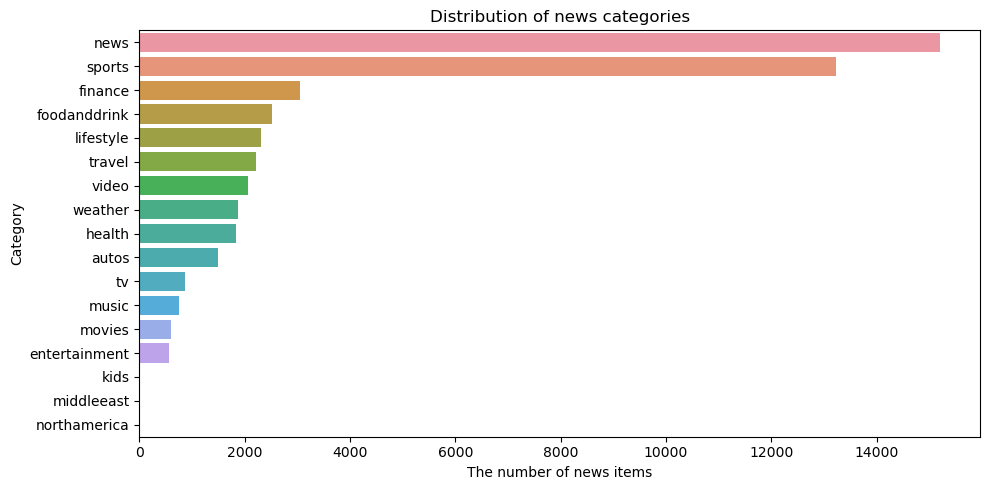

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.countplot(data=news_clean, y='Category', order=news_clean['Category'].value_counts().index)
plt.title('Distribution of news categories')
plt.xlabel('The number of news items')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

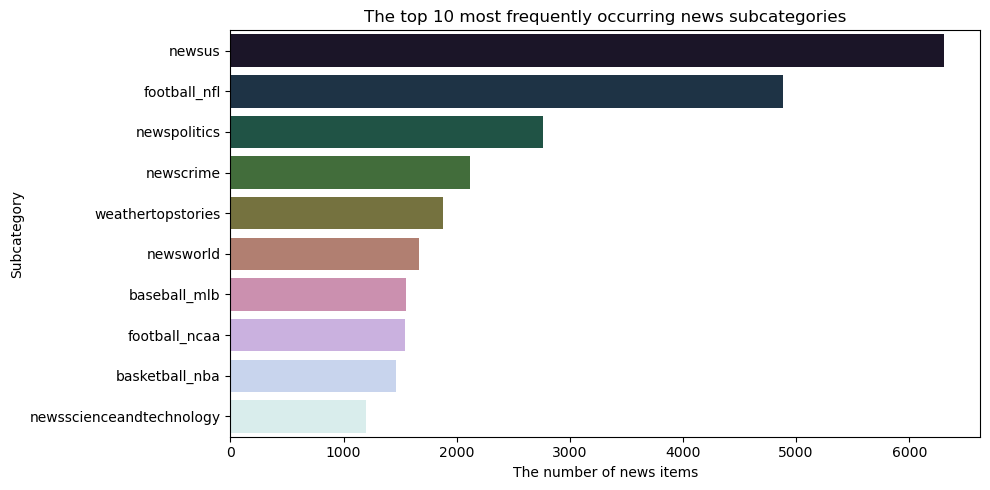

In [38]:
top_subcat = news_clean['SubCategory'].value_counts().head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_subcat.values, y=top_subcat.index, palette='cubehelix')
plt.title('The top 10 most frequently occurring news subcategories')
plt.xlabel('The number of news items')
plt.ylabel('Subcategory')
plt.tight_layout()
plt.show()

/tmp/ipykernel_3123/3542252221.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  news_clean['title_length'] = news_clean['Title'].apply(lambda x: len(str(x).split()))
/tmp/ipykernel_3123/3542252221.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  news_clean['abstract_length'] = news_clean['Abstract'].apply(lambda x: len(str(x).split()))
/home/raymo/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. 

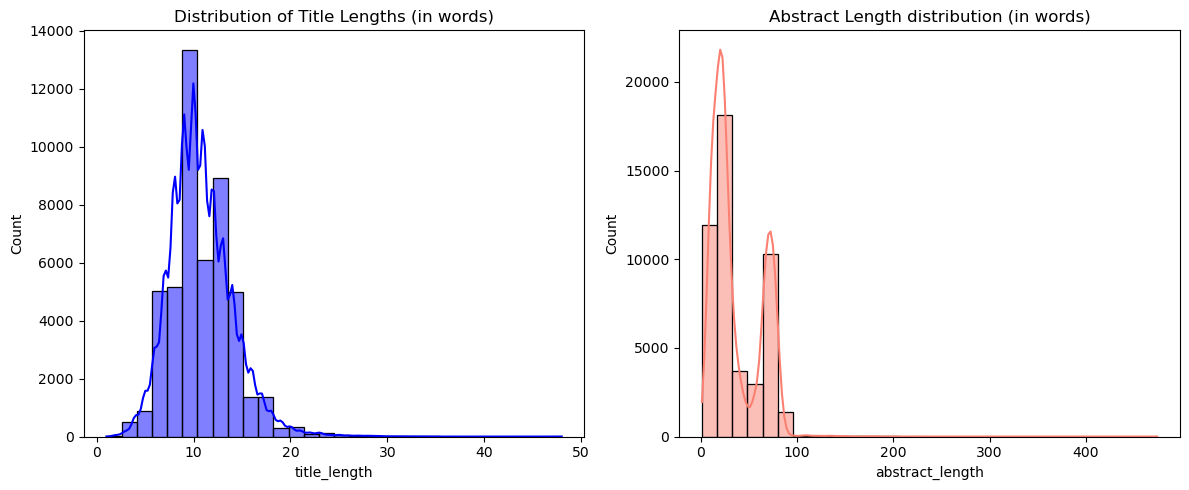

In [39]:
news_clean['title_length'] = news_clean['Title'].apply(lambda x: len(str(x).split()))
news_clean['abstract_length'] = news_clean['Abstract'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(news_clean['title_length'], bins=30, kde=True, color='blue')
plt.title('Distribution of Title Lengths (in words)')

plt.subplot(1, 2, 2)
sns.histplot(news_clean['abstract_length'], bins=30, kde=True, color='salmon')
plt.title('Abstract Length distribution (in words)')

plt.tight_layout()
plt.show()

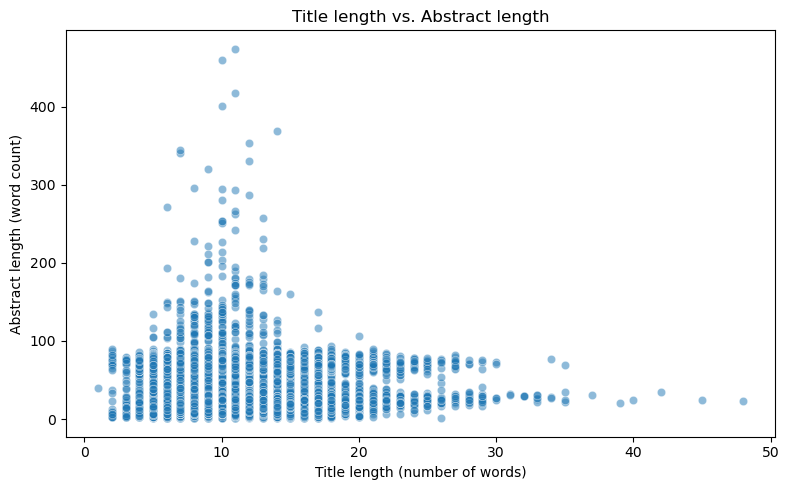

In [40]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=news_clean, x='title_length', y='abstract_length', alpha=0.5)
plt.title('Title length vs. Abstract length')
plt.xlabel('Title length (number of words)')
plt.ylabel('Abstract length (word count)')
plt.tight_layout()
plt.show()

In [41]:
# from wordcloud import WordCloud

# text_all_titles = ' '.join(news_clean['Title'].dropna())
# wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='viridis').generate(text_all_titles)

# plt.figure(figsize=(10, 5))
# plt.imshow(wordcloud, interpolation='bilinear')
# plt.axis('off')
# plt.title('News headline word cloud')
# plt.tight_layout()
# plt.show()

#### 2.2.2 EDA of user behavior data

User's historical click-through count

count    153727.000000
mean          6.414989
std           1.376883
min           1.000000
25%           7.000000
50%           7.000000
75%           7.000000
max           7.000000
Name: history_len, dtype: float64


/tmp/ipykernel_3123/374645258.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  behaviors_clean['history_len'] = behaviors_clean['History'].fillna('').apply(lambda x: len(x.split()) if x else 0)


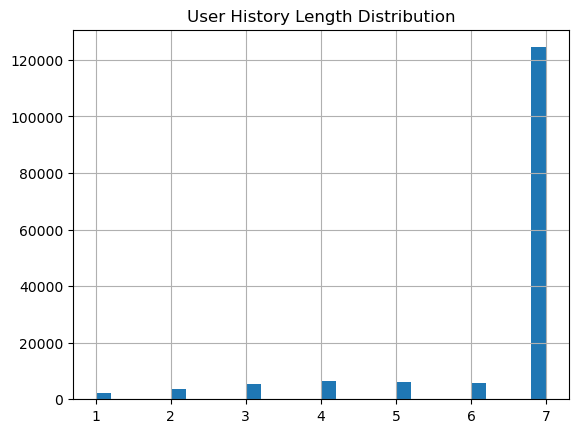

In [42]:
behaviors_clean['history_len'] = behaviors_clean['History'].fillna('').apply(lambda x: len(x.split()) if x else 0)
print(behaviors_clean['history_len'].describe())

behaviors_clean['history_len'].hist(bins=30)
plt.title('User History Length Distribution')
plt.show()


The number of impressions of news each time

/tmp/ipykernel_3123/1653376557.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  behaviors_clean['impr_num'] = behaviors_clean['Impressions'].apply(lambda x: len(x.split()))


count    153727.000000
mean         37.228346
std          38.575186
min           2.000000
25%          10.000000
50%          24.000000
75%          51.000000
max         299.000000
Name: impr_num, dtype: float64


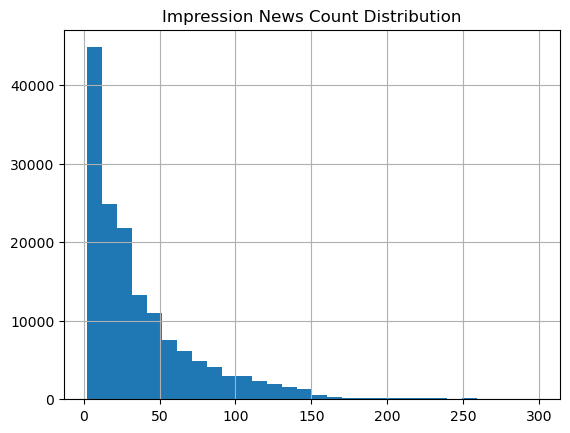

In [43]:
behaviors_clean['impr_num'] = behaviors_clean['Impressions'].apply(lambda x: len(x.split()))
print(behaviors_clean['impr_num'].describe())

behaviors_clean['impr_num'].hist(bins=30)
plt.title('Impression News Count Distribution')
plt.show()


#### The click-through rate per exposure

In [44]:
behaviors_clean

,Impression_ID,User_ID,Time,History,Impressions,Impressions_parsed,History_parsed,history_len,impr_num
0,1,U13740,11/11/2019 9:05:58 AM,N34694 N45794 N18445 N63302 N10414 N19347 N31801,N55689-1 N35729-0,"[(N55689, 1), (N35729, 0)]","[N34694, N45794, N18445, N63302, N10414, N1934...",7,2
1,2,U91836,11/12/2019 6:11:30 PM,N35458 N24611 N37509 N21773 N41011 N19041 N25785,N20678-0 N39317-0 N58114-0 N20495-0 N42977-0 N...,"[(N20678, 0), (N39317, 0), (N58114, 0), (N2049...","[N35458, N24611, N37509, N21773, N41011, N1904...",7,11
2,3,U73700,11/14/2019 7:01:48 AM,N33164 N47289 N24233 N62058 N26378 N49475 N18870,N50014-0 N23877-0 N35389-0 N49712-0 N16844-0 N...,"[(N50014, 0), (N23877, 0), (N35389, 0), (N4971...","[N33164, N47289, N24233, N62058, N26378, N4947...",7,36
3,4,U34670,11/11/2019 5:28:05 AM,N53880 N41375 N43142 N33013 N29757 N31825 N51891,N35729-0 N33632-0 N49685-1 N27581-0,"[(N35729, 0), (N33632, 0), (N49685, 1), (N2758...","[N53880, N41375, N43142, N33013, N29757, N3182...",7,4
4,5,U8125,11/12/2019 4:11:21 PM,N10078 N56514 N14904 N33740,N39985-0 N36050-0 N16096-0 N8400-1 N22407-0 N6...,"[(N39985, 0), (N36050, 0), (N16096, 0), (N8400...","[N10078, N56514, N14904, N33740]",4,69
...,...,...,...,...,...,...,...,...,...
156960,156961,U21593,11/14/2019 10:24:05 PM,N46473 N4607 N62957 N8148 N38783 N24803 N48925,N2235-0 N22975-0 N64037-0 N47652-0 N11378-0 N4...,"[(N2235, 0), (N22975, 0), (N64037, 0), (N47652...","[N46473, N4607, N62957, N8148, N38783, N24803,...",7,31
156961,156962,U10123,11/13/2019 6:57:04 AM,N42128 N2078 N49475 N57239 N28203 N5527 N40509,N3841-0 N61571-0 N58813-0 N28213-0 N4428-0 N25...,"[(N3841, 0), (N61571, 0), (N58813, 0), (N28213...","[N42128, N2078, N49475, N57239, N28203, N5527,...",7,89
156962,156963,U75630,11/14/2019 10:58:13 AM,N12844 N47277 N7328 N53880 N16710 N8270 N29510,N55913-0 N62318-0 N53515-0 N10960-0 N9135-0 N5...,"[(N55913, 0), (N62318, 0), (N53515, 0), (N1096...","[N12844, N47277, N7328, N53880, N16710, N8270,...",7,43
156963,156964,U44625,11/13/2019 2:57:02 PM,N52355 N42330 N19335 N3128 N43083 N9288 N37863,N6219-0 N3663-0 N31147-0 N58363-0 N4107-0 N457...,"[(N6219, 0), (N3663, 0), (N31147, 0), (N58363,...","[N52355, N42330, N19335, N3128, N43083, N9288,...",7,119


In [45]:
def get_ctr(imp_str):
    if pd.isna(imp_str): return 0
    return sum(int(i.split('-')[1]) for i in imp_str.split()) / len(imp_str.split())

behaviors_clean['impr_ctr'] = behaviors_clean['Impressions'].apply(get_ctr)
print(behaviors_clean['impr_ctr'].describe())

count    153727.000000
mean          0.108548
std           0.129526
min           0.003367
25%           0.028571
50%           0.055556
75%           0.125000
max           0.750000
Name: impr_ctr, dtype: float64


/tmp/ipykernel_3123/3929120853.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  behaviors_clean['impr_ctr'] = behaviors_clean['Impressions'].apply(get_ctr)


/tmp/ipykernel_3123/3096402538.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  behaviors_clean['ctr_bin'] = pd.cut(behaviors_clean['impr_ctr'], bins=bins, labels=labels, include_lowest=True)


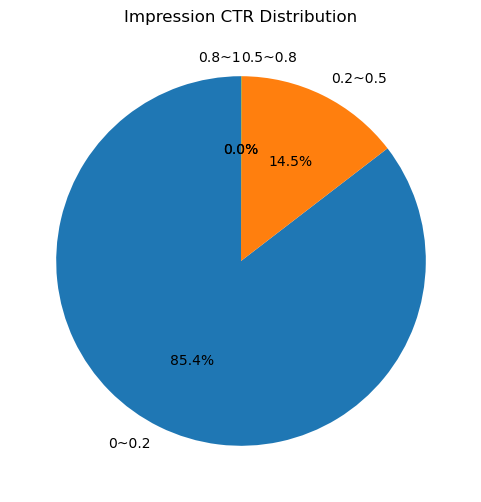

In [46]:
import matplotlib.pyplot as plt

# 分箱（你可以调整bins的范围以适应你的实际数据）
bins = [0, 0.2, 0.5, 0.8, 1]
labels = ['0~0.2', '0.2~0.5', '0.5~0.8', '0.8~1']
behaviors_clean['ctr_bin'] = pd.cut(behaviors_clean['impr_ctr'], bins=bins, labels=labels, include_lowest=True)

# 统计每个区间数量
bin_counts = behaviors_clean['ctr_bin'].value_counts().sort_index()

# 画饼图
plt.figure(figsize=(6, 6))
plt.pie(bin_counts, labels=bin_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Impression CTR Distribution')
plt.show()


#### explains

1. **Distribution of News categories**
- Dominant categories: **news** and **sports**
The data distribution is unbalanced
Niche categories (such as *kids*, *middleeast*) belong to the ** long-tail distribution **

2. **Top-10 Subcategories **
The subcategories **newsus**, **football_nfl**, and **baseball_mlb** have the highest occurrence frequency
The *news* category has a high degree of diversity: demonstrating the potential for ** more fine-grained personalized recommendations **

3. Title and Abstract Length
- **Title** : Most are 10 to 15 words
- **Abstract** : Most are 30 to 100 words
For using "TF-IDF" to represent text features, such a length is already quite informative

4. Scatter plot of the lengths of the title and abstract
- No strong correlation: This indicates that the Title and Abstract are complementary information
Support merging the two into 'full_text' as a **joint input feature**

5. "Word Cloud Analysis of News Headlines
- the most common words include: "Trump", "New ", "say", "game", "week"
- The displayed news focuses on politics and sports, which can serve as a basis for themes or entity-level features

# 3. Feature Engineering

### 3.1 Feature Extraction`full_text`

In [47]:
news_clean['full_text'] = news_clean['Title'] + '. ' + news_clean['Abstract']
display(news_clean[['News_ID', 'Category', 'full_text']].head(3))

/tmp/ipykernel_3123/729367934.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  news_clean['full_text'] = news_clean['Title'] + '. ' + news_clean['Abstract']


,News_ID,Category,full_text
0,N55528,lifestyle,"The Brands Queen Elizabeth, Prince Charles, an..."
1,N19639,health,50 Worst Habits For Belly Fat. These seemingly...
2,N61837,news,The Cost of Trump's Aid Freeze in the Trenches...


#### 3.2 data clearning

In [48]:
import nltk
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer

nltk.download('stopwords')
nltk.download('punkt_tab')
nltk.download('punkt')
ps = PorterStemmer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'\s+', ' ', text)
    text=re.sub(r"[^\w\s'\-]", ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()                # Remove extra spaces
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words]
    tokens = [ps.stem(word) for word in tokens]
    return ' '.join(tokens)

news_clean['full_text_clean'] = news_clean['full_text'].apply(preprocess_text)

[nltk_data] Downloading package stopwords to /home/raymo/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/raymo/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to /home/raymo/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
/tmp/ipykernel_3123/139281858.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  news_clean['full_text_clean'] = news_clean['full_text'].apply(preprocess_text)


In [49]:
news_clean.head(),news_clean.describe()

(  News_ID   Category      SubCategory  \
 0  N55528  lifestyle  lifestyleroyals   
 1  N19639     health       weightloss   
 2  N61837       news        newsworld   
 3  N53526     health           voices   
 4  N38324     health          medical   
 
                                                Title  \
 0  The Brands Queen Elizabeth, Prince Charles, an...   
 1                      50 Worst Habits For Belly Fat   
 2  The Cost of Trump's Aid Freeze in the Trenches...   
 3  I Was An NBA Wife. Here's How It Affected My M...   
 4  How to Get Rid of Skin Tags, According to a De...   
 
                                             Abstract  \
 0  Shop the notebooks, jackets, and more that the...   
 1  These seemingly harmless habits are holding yo...   
 2  Lt. Ivan Molchanets peeked over a parapet of s...   
 3  I felt like I was a fraud, and being an NBA wi...   
 4  They seem harmless, but there's a very good re...   
 
                                              URL  \
 0  h

The design purpose of this merge operation is to combine the brief information (title) with the more complete information (summary) as the input representation in the TF-IDF model. This step is very common in content-based recommendation systems because it can enhance semantic context (Ramos, 2003).

#### Export Data

In [50]:
# news_clean.to_csv("news_clean.csv",index=False)

## 3.2. Create interactive df

For the Collaborative Filtering approach, an explicit data structure is required, consisting of User_ID, News_ID, and Label pairs (1 for clicked, 0 for not clicked).
This data is constructed by parsing the Impressions column from the behaviors_clean dataset.

In [51]:
interactions_flat = []

for row in behaviors_clean.itertuples(index=False):  # ALREADY REVISED
    user_id = row.User_ID
    impressions = row.Impressions.split()
    for impression in impressions:
        if '-' in impression:
            news_id, label = impression.rsplit('-', 1)
            interactions_flat.append((user_id, news_id, int(label)))

interactions_df = pd.DataFrame(interactions_flat, columns=['User_ID', 'News_ID', 'Label'])
print("Total interactions:", len(interactions_df))


Total interactions: 5723002


In [52]:
interactions_df

,User_ID,News_ID,Label
0,U13740,N55689,1
1,U13740,N35729,0
2,U91836,N20678,0
3,U91836,N39317,0
4,U91836,N58114,0
...,...,...,...
5722997,U44625,N39317,0
5722998,U64800,N61233,0
5722999,U64800,N33828,1
5723000,U64800,N19661,0


In [53]:
interactions_df.groupby('Label')['Label'].value_counts()

Label
0    5491472
1     231530
Name: count, dtype: int64

In [54]:
news_category = news_clean[['News_ID', 'Category']]
interactions_df = interactions_df.merge(news_category, on='News_ID', how='left')


In [55]:
interactions_df.head()

,User_ID,News_ID,Label,Category
0,U13740,N55689,1,sports
1,U13740,N35729,0,news
2,U91836,N20678,0,sports
3,U91836,N39317,0,news
4,U91836,N58114,0,NaN


## 3.3. TF-IDF Feature Extraction

As a feature for Content-Based Filtering, text representation is extracted using the TF-IDF (Term Frequency–Inverse Document Frequency) method, which considers word importance based on both local and global occurrence.

## 3.4. Label Encoding for Collaborative Filtering

In [56]:
user_encoder = LabelEncoder()
news_encoder = LabelEncoder()

interactions_df['user_encoded'] = user_encoder.fit_transform(interactions_df['User_ID'])
interactions_df['news_encoded'] = news_encoder.fit_transform(interactions_df['News_ID'])

num_users = interactions_df['user_encoded'].nunique()
num_items = interactions_df['news_encoded'].nunique()

print(f"Number of unique users: {num_users}")
print(f"Number of unique news items: {num_items}")

Number of unique users: 49108
Number of unique news items: 20252


In [57]:
interactions_df

,User_ID,News_ID,Label,Category,user_encoded,news_encoded
0,U13740,N55689,1,sports,2201,15659
1,U13740,N35729,0,news,2201,8792
2,U91836,N20678,0,sports,47474,3670
3,U91836,N39317,0,news,47474,10061
4,U91836,N58114,0,NaN,47474,16502
...,...,...,...,...,...,...
5722997,U44625,N39317,0,news,20012,10061
5722998,U64800,N61233,0,weather,31669,17625
5722999,U64800,N33828,1,movies,31669,8140
5723000,U64800,N19661,0,news,31669,3330


#### Notes:
Encoding:
- Specific to the architecture of the Collaborative Filtering model
- Encoding depends on the number and distribution of users and items

## 3.5. Data Splitting for Train-Test (training model)

In [58]:
X = interactions_df[['user_encoded', 'news_encoded']]
y = interactions_df['Label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

Stratified sampling is conducted according to the category ratio of y to ensure that the ratio of positive and negative samples (such as clicked and unclicked) in the training set and the test set remains consistent.

In [59]:
X_train, y_train

(         user_encoded  news_encoded
 3096247         36835          8081
 3421183         34182          5319
 4427003          6382         17181
 3083783         21848         15169
 2205544         27269         11868
 ...               ...           ...
 5052751          6796         13639
 2466162          2459          3527
 4767759         26459         12484
 152220          47161          3464
 4509053         15867         15321
 
 [4578401 rows x 2 columns],
 3096247    0
 3421183    0
 4427003    0
 3083783    0
 2205544    0
           ..
 5052751    0
 2466162    0
 4767759    0
 152220     0
 4509053    0
 Name: Label, Length: 4578401, dtype: int64)

# 4. Experiment

### 4.1. Content Based Filtering - TF-IDF

The Content-Based Filtering approach recommends news based on content similarity between articles, without taking into account the behavior of other users.
News content is represented by transforming the combined text of Title + Abstract into a fixed-dimensional TF-IDF vector.
Then, a k-Nearest Neighbors (k-NN) algorithm based on cosine similarity is used to find the most similar news articles.

In [155]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import pandas as pd

# find the best max_features 
feature_range = [1000, 3000, 5000, 7000, 10000]
K = 10
results = []

for max_f in feature_range:
    print(f"\n Testing max_features = {max_f}")

    # TF-IDF 生成
    vectorizer = TfidfVectorizer(max_features=max_f)
    tfidf_matrix = vectorizer.fit_transform(news_clean['full_text_clean'])
    newsid2idx = {nid: i for i, nid in enumerate(news_clean['News_ID'])}

    # 用户兴趣向量
    def get_user_profile(history_list):
        indices = [newsid2idx[nid] for nid in history_list if nid in newsid2idx]
        if not indices:
            return np.zeros((tfidf_matrix.shape[1],))
        return tfidf_matrix[indices].mean(axis=0).A1

    # 推荐函数
    def recommend_for_row(row, K=K):
        history = row['History'].split() if pd.notna(row['History']) else []
        user_vec = get_user_profile(history).reshape(1, -1)
        impression_items = row['Impressions'].split()
        candidates = [item.split('-')[0] for item in impression_items]
        candidate_idxs = [newsid2idx[nid] for nid in candidates if nid in newsid2idx]
        if not candidate_idxs:
            return []
        candidate_vecs = tfidf_matrix[candidate_idxs]
        sims = cosine_similarity(user_vec, candidate_vecs).flatten()
        topk_idx = np.argsort(sims)[-K:][::-1]
        return [candidates[i] for i in topk_idx]

    # 生成推荐
    behaviors_clean['cb_recommend'] = behaviors_clean.apply(lambda row: recommend_for_row(row, K), axis=1)

    # 评估指标
    def calc_precision(row):
        actual = set([i.split('-')[0] for i in row['Impressions'].split() if i.endswith('-1')])
        recs = row['cb_recommend'][:K] if isinstance(row['cb_recommend'], list) else []
        return sum(1 for nid in recs if nid in actual) / K if recs else 0

    def calc_mrr(row):
        actual = set([i.split('-')[0] for i in row['Impressions'].split() if i.endswith('-1')])
        recs = row['cb_recommend'][:K] if isinstance(row['cb_recommend'], list) else []
        for idx, nid in enumerate(recs, 1):
            if nid in actual:
                return 1 / idx
        return 0

    def calc_ndcg(row):
        actual = set([i.split('-')[0] for i in row['Impressions'].split() if i.endswith('-1')])
        recs = row['cb_recommend'][:K] if isinstance(row['cb_recommend'], list) else []
        dcg = sum(1 / np.log2(i + 2) for i, nid in enumerate(recs) if nid in actual)
        idcg = sum(1 / np.log2(i + 2) for i in range(min(len(actual), K)))
        return dcg / idcg if idcg > 0 else 0

    behaviors_clean['precision'] = behaviors_clean.apply(calc_precision, axis=1)
    behaviors_clean['mrr'] = behaviors_clean.apply(calc_mrr, axis=1)
    behaviors_clean['ndcg'] = behaviors_clean.apply(calc_ndcg, axis=1)

    results.append({
        'max_features': max_f,
        'precision@10': behaviors_clean['precision'].mean(),
        'mrr@10': behaviors_clean['mrr'].mean(),
        'ndcg@10': behaviors_clean['ndcg'].mean(),
    })

# 转换为 DataFrame 并显示
results_df = pd.DataFrame(results)
best_row = results_df.sort_values(by='ndcg@10', ascending=False).iloc[0]

print("\nAll results:")
print(results_df)

print(f"\nBest max_features found: {best_row['max_features']} with:")
print(f" - Precision@10: {best_row['precision@10']:.4f}")
print(f" - MRR@10:       {best_row['mrr@10']:.4f}")
print(f" - NDCG@10:      {best_row['ndcg@10']:.4f}")



 Testing max_features = 1000


/tmp/ipykernel_18265/39228014.py:41: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  behaviors_clean['cb_recommend'] = behaviors_clean.apply(lambda row: recommend_for_row(row, K), axis=1)
/tmp/ipykernel_18265/39228014.py:64: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  behaviors_clean['precision'] = behaviors_clean.apply(calc_precision, axis=1)
/tmp/ipykernel_18265/39228014.py:65: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexe


 Testing max_features = 3000


/tmp/ipykernel_18265/39228014.py:41: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  behaviors_clean['cb_recommend'] = behaviors_clean.apply(lambda row: recommend_for_row(row, K), axis=1)
/tmp/ipykernel_18265/39228014.py:64: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  behaviors_clean['precision'] = behaviors_clean.apply(calc_precision, axis=1)
/tmp/ipykernel_18265/39228014.py:65: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexe


 Testing max_features = 5000


...

/tmp/ipykernel_18265/39228014.py:41: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  behaviors_clean['cb_recommend'] = behaviors_clean.apply(lambda row: recommend_for_row(row, K), axis=1)
/tmp/ipykernel_18265/39228014.py:64: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  behaviors_clean['precision'] = behaviors_clean.apply(calc_precision, axis=1)
/tmp/ipykernel_18265/39228014.py:65: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexe


 Testing max_features = 10000


/tmp/ipykernel_18265/39228014.py:41: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  behaviors_clean['cb_recommend'] = behaviors_clean.apply(lambda row: recommend_for_row(row, K), axis=1)
/tmp/ipykernel_18265/39228014.py:64: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  behaviors_clean['precision'] = behaviors_clean.apply(calc_precision, axis=1)
/tmp/ipykernel_18265/39228014.py:65: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexe


All results:
   max_features  precision@10    mrr@10   ndcg@10
0          1000      0.065233  0.258304  0.309604
1          3000      0.065873  0.263632  0.314381
2          5000      0.065899  0.263592  0.314271
3          7000      0.065834  0.262881  0.313666
4         10000      0.065697  0.262348  0.313087

Best max_features found: 3000.0 with:
 - Precision@10: 0.0659
 - MRR@10:       0.2636
 - NDCG@10:      0.3144


/tmp/ipykernel_18265/39228014.py:66: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  behaviors_clean['ndcg'] = behaviors_clean.apply(calc_ndcg, axis=1)


In [156]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)
tfidf_matrix = vectorizer.fit_transform(news_clean['full_text_clean'])
# Establish the mapping from News_ID to the vector row number
newsid2idx = {nid: i for i, nid in enumerate(news_clean['News_ID'])}


In [157]:
import numpy as np

def get_user_profile(history_list):
    indices = [newsid2idx[nid] for nid in history_list if nid in newsid2idx]
    if not indices:  # If the user has no history
        return np.zeros((tfidf_matrix.shape[1],))
    # Take the average TF-IDF of historical click news
    return tfidf_matrix[indices].mean(axis=0).A1  #.A1 convert to one-dimensional numpy


In [158]:
from sklearn.metrics.pairwise import cosine_similarity

def recommend_for_row(row, K=5):
    # Take history in every row
    history = row['History'].split() if pd.notna(row['History']) else []
    user_vec = get_user_profile(history).reshape(1, -1)
    # Candidate news in "Impression"
    impression_items = row['Impressions'].split()
    candidates = [item.split('-')[0] for item in impression_items]
    # Find the vector index of each candidate news
    candidate_idxs = [newsid2idx[nid] for nid in candidates if nid in newsid2idx]
    # If there is no candidate news vector, return empty
    if not candidate_idxs:
        return []
    candidate_vecs = tfidf_matrix[candidate_idxs]
    # Calculate similarity
    sims = cosine_similarity(user_vec, candidate_vecs).flatten()
    # Sort by similarity and take the TopK
    topk_idx = np.argsort(sims)[-K:][::-1]
    # Return the news ids sorted by relevance within "Impression"
    return [candidates[i] for i in topk_idx]

# Recommended, K can be customized
K = 10
behaviors_clean['cb_recommend'] = behaviors_clean.apply(lambda row: recommend_for_row(row, K=K), axis=1)

/tmp/ipykernel_18265/800103377.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  behaviors_clean['cb_recommend'] = behaviors_clean.apply(lambda row: recommend_for_row(row, K=K), axis=1)


In [159]:
behaviors_clean.head()

,Impression_ID,User_ID,Time,History,Impressions,Impressions_parsed,History_parsed,history_len,impr_num,impr_ctr,ctr_bin,cb_recommend,precision,mrr,ndcg
0,1,U13740,11/11/2019 9:05:58 AM,N34694 N45794 N18445 N63302 N10414 N19347 N31801,N55689-1 N35729-0,"[(N55689, 1), (N35729, 0)]","[N34694, N45794, N18445, N63302, N10414, N1934...",7,2,0.500000,0.2~0.5,"[N55689, N35729]",0.1,1.000000,1.00000
1,2,U91836,11/12/2019 6:11:30 PM,N35458 N24611 N37509 N21773 N41011 N19041 N25785,N20678-0 N39317-0 N58114-0 N20495-0 N42977-0 N...,"[(N20678, 0), (N39317, 0), (N58114, 0), (N2049...","[N35458, N24611, N37509, N21773, N41011, N1904...",7,11,0.090909,0~0.2,"[N58114, N20495, N14592, N39317, N20678, N7821...",0.1,0.111111,0.30103
2,3,U73700,11/14/2019 7:01:48 AM,N33164 N47289 N24233 N62058 N26378 N49475 N18870,N50014-0 N23877-0 N35389-0 N49712-0 N16844-0 N...,"[(N50014, 0), (N23877, 0), (N35389, 0), (N4971...","[N33164, N47289, N24233, N62058, N26378, N4947...",7,36,0.027778,0~0.2,"[N50592, N47346, N16844, N50014, N48722, N4887...",0.1,0.111111,0.30103
3,4,U34670,11/11/2019 5:28:05 AM,N53880 N41375 N43142 N33013 N29757 N31825 N51891,N35729-0 N33632-0 N49685-1 N27581-0,"[(N35729, 0), (N33632, 0), (N49685, 1), (N2758...","[N53880, N41375, N43142, N33013, N29757, N3182...",7,4,0.250000,0.2~0.5,"[N35729, N49685, N33632]",0.1,0.500000,0.63093
4,5,U8125,11/12/2019 4:11:21 PM,N10078 N56514 N14904 N33740,N39985-0 N36050-0 N16096-0 N8400-1 N22407-0 N6...,"[(N39985, 0), (N36050, 0), (N16096, 0), (N8400...","[N10078, N56514, N14904, N33740]",4,69,0.014493,0~0.2,"[N33885, N60408, N305, N50023, N36807, N16096,...",0.0,0.000000,0.00000


In [160]:
def calc_precision_at_k(row, K=10):
    # Impression中的实际点击新闻ID集合
    actual_clicks = set([item.split('-')[0] for item in row['Impressions'].split() if item.endswith('-1')])
    recommended = row['cb_recommend'][:K] if isinstance(row['cb_recommend'], list) else []
    if not recommended:
        return 0
    hit = sum([1 for nid in recommended if nid in actual_clicks])
    return hit / K

behaviors_clean['precision@K'] = behaviors_clean.apply(lambda row: calc_precision_at_k(row, K=K), axis=1)
print(f'Content-based Precision@{K}:', behaviors_clean['precision@K'].mean())


Content-based Precision@10: 0.06589928899932998


/tmp/ipykernel_18265/3831116175.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  behaviors_clean['precision@K'] = behaviors_clean.apply(lambda row: calc_precision_at_k(row, K=K), axis=1)


In [161]:
def calc_recall_at_k(row, K=5):
    actual_clicks = set([item.split('-')[0] for item in row['Impressions'].split() if item.endswith('-1')])
    recommended = row['cb_recommend'][:K] if isinstance(row['cb_recommend'], list) else []
    if not actual_clicks:
        return 0
    hit = sum([1 for nid in recommended if nid in actual_clicks])
    return hit / len(actual_clicks)

behaviors_clean['recall@K'] = behaviors_clean.apply(lambda row: calc_recall_at_k(row, K=K), axis=1)
print(f'Content-based Recall@{K}:', behaviors_clean['recall@K'].mean())


Content-based Recall@10: 0.5260664235492958


/tmp/ipykernel_18265/935548249.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  behaviors_clean['recall@K'] = behaviors_clean.apply(lambda row: calc_recall_at_k(row, K=K), axis=1)


In [162]:
def calc_mrr_at_k(row, K=5):
    actual_clicks = set([item.split('-')[0] for item in row['Impressions'].split() if item.endswith('-1')])
    recommended = row['cb_recommend'][:K] if isinstance(row['cb_recommend'], list) else []
    for idx, nid in enumerate(recommended, 1):  # 1-based
        if nid in actual_clicks:
            return 1.0 / idx
    return 0

behaviors_clean['mrr@K'] = behaviors_clean.apply(lambda row: calc_mrr_at_k(row, K=K), axis=1)
print(f'Content-based MRR@{K}:', behaviors_clean['mrr@K'].mean())


Content-based MRR@10: 0.2635919055022401


/tmp/ipykernel_18265/3014698030.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  behaviors_clean['mrr@K'] = behaviors_clean.apply(lambda row: calc_mrr_at_k(row, K=K), axis=1)


In [163]:
def evaluate_hit(row):
    clicked = [item.split('-')[0] for item in row['Impressions'].split() if item.endswith('-1')]
    recommended = row['cb_recommend']
    return int(any(news in clicked for news in recommended))

behaviors_clean['hit'] = behaviors_clean.apply(evaluate_hit, axis=1)
hit_rate = behaviors_clean['hit'].mean()
print(f"Hit Rate@{K}: {hit_rate:.4f}")


Hit Rate@10: 0.5921


/tmp/ipykernel_18265/2294879994.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  behaviors_clean['hit'] = behaviors_clean.apply(evaluate_hit, axis=1)


In [164]:
behaviors_clean.head()

,Impression_ID,User_ID,Time,History,Impressions,Impressions_parsed,History_parsed,history_len,impr_num,impr_ctr,ctr_bin,cb_recommend,precision,mrr,ndcg,precision@K,recall@K,mrr@K,hit
0,1,U13740,11/11/2019 9:05:58 AM,N34694 N45794 N18445 N63302 N10414 N19347 N31801,N55689-1 N35729-0,"[(N55689, 1), (N35729, 0)]","[N34694, N45794, N18445, N63302, N10414, N1934...",7,2,0.500000,0.2~0.5,"[N55689, N35729]",0.1,1.000000,1.00000,0.1,1.0,1.000000,1
1,2,U91836,11/12/2019 6:11:30 PM,N35458 N24611 N37509 N21773 N41011 N19041 N25785,N20678-0 N39317-0 N58114-0 N20495-0 N42977-0 N...,"[(N20678, 0), (N39317, 0), (N58114, 0), (N2049...","[N35458, N24611, N37509, N21773, N41011, N1904...",7,11,0.090909,0~0.2,"[N58114, N20495, N14592, N39317, N20678, N7821...",0.1,0.111111,0.30103,0.1,1.0,0.111111,1
2,3,U73700,11/14/2019 7:01:48 AM,N33164 N47289 N24233 N62058 N26378 N49475 N18870,N50014-0 N23877-0 N35389-0 N49712-0 N16844-0 N...,"[(N50014, 0), (N23877, 0), (N35389, 0), (N4971...","[N33164, N47289, N24233, N62058, N26378, N4947...",7,36,0.027778,0~0.2,"[N50592, N47346, N16844, N50014, N48722, N4887...",0.1,0.111111,0.30103,0.0,0.0,0.000000,0
3,4,U34670,11/11/2019 5:28:05 AM,N53880 N41375 N43142 N33013 N29757 N31825 N51891,N35729-0 N33632-0 N49685-1 N27581-0,"[(N35729, 0), (N33632, 0), (N49685, 1), (N2758...","[N53880, N41375, N43142, N33013, N29757, N3182...",7,4,0.250000,0.2~0.5,"[N35729, N49685, N33632]",0.1,0.500000,0.63093,0.1,1.0,0.500000,1
4,5,U8125,11/12/2019 4:11:21 PM,N10078 N56514 N14904 N33740,N39985-0 N36050-0 N16096-0 N8400-1 N22407-0 N6...,"[(N39985, 0), (N36050, 0), (N16096, 0), (N8400...","[N10078, N56514, N14904, N33740]",4,69,0.014493,0~0.2,"[N33885, N60408, N305, N50023, N36807, N16096,...",0.0,0.000000,0.00000,0.0,0.0,0.000000,0


In [165]:
import numpy as np

def calc_ndcg_at_k(row, K=10):
    actual_clicks = set([item.split('-')[0] for item in row['Impressions'].split() if item.endswith('-1')])
    recommended = row['cb_recommend'][:K] if isinstance(row['cb_recommend'], list) else []
    
    dcg = 0.0
    for i, nid in enumerate(recommended):
        if nid in actual_clicks:
            dcg += 1.0 / np.log2(i + 2)  # i+2 for 1-based position
    
    ideal_len = min(len(actual_clicks), K)
    if ideal_len == 0:
        return 0.0
    idcg = sum(1.0 / np.log2(i + 2) for i in range(ideal_len))  # ideal DCG

    return dcg / idcg


In [166]:
from sklearn.metrics import roc_auc_score

def calc_auc(row):
    items = row['Impressions'].split()
    labels = []
    scores = []
    actual_clicks = set([item.split('-')[0] for item in items if item.endswith('-1')])
    recommended = row['cb_recommend'] if isinstance(row['cb_recommend'], list) else []
    
    candidate_ids = [item.split('-')[0] for item in items]
    
    for nid in candidate_ids:
        labels.append(1 if nid in actual_clicks else 0)
        # 如果推荐分数不在 Top-K 中，用 0 分处理
        scores.append(len(recommended) - recommended.index(nid) if nid in recommended else 0)
    
    # 至少需要正负样本
    if len(set(labels)) < 2:
        return None
    
    return roc_auc_score(labels, scores)


In [167]:
behaviors_clean['ndcg@K'] = behaviors_clean.apply(lambda row: calc_ndcg_at_k(row, K=K), axis=1)
behaviors_clean['auc'] = behaviors_clean.apply(calc_auc, axis=1)

# 平均 NDCG 和 AUC（过滤掉无效行）
ndcg_mean = behaviors_clean['ndcg@K'].mean()
auc_mean = behaviors_clean['auc'].dropna().mean()

print(f'NDCG@{K}: {ndcg_mean:.4f}')
print(f'AUC: {auc_mean:.4f}')


/tmp/ipykernel_18265/853345121.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  behaviors_clean['ndcg@K'] = behaviors_clean.apply(lambda row: calc_ndcg_at_k(row, K=K), axis=1)


NDCG@10: 0.3143
AUC: 0.5295


/tmp/ipykernel_18265/853345121.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  behaviors_clean['auc'] = behaviors_clean.apply(calc_auc, axis=1)


# Content Base - Bert

In [168]:
from transformers import BertTokenizer, BertModel
import torch
from tqdm import tqdm
import numpy as np

# 加载原始 BERT 模型
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
bert_model = BertModel.from_pretrained('bert-base-uncased')
bert_model.eval()
bert_model.cuda()  # 如果有GPU

# 准备文本输入（可用 Title + Abstract）
texts = (news_clean['Title'].fillna('') + ' ' + news_clean['Abstract'].fillna('')).tolist()

# 编码函数：提取 [CLS]
def get_bert_cls_embeddings(texts, batch_size=32, max_len=128):
    embeddings = []
    for i in tqdm(range(0, len(texts), batch_size)):
        batch_texts = texts[i:i+batch_size]
        inputs = tokenizer(batch_texts, padding=True, truncation=True, max_length=max_len, return_tensors='pt')
        inputs = {k: v.cuda() for k, v in inputs.items()}
        with torch.no_grad():
            outputs = bert_model(**inputs)
            cls_vecs = outputs.last_hidden_state[:, 0, :]  # shape: (batch_size, 768)
        embeddings.append(cls_vecs.cpu().numpy())
    return np.vstack(embeddings)

bert_news_embeddings = get_bert_cls_embeddings(texts)


  0%|          | 0/1520 [00:00<?, ?it/s]/home/raymo/anaconda3/lib/python3.11/site-packages/torch/nn/modules/module.py:1541: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
100%|██████████| 1520/1520 [01:32<00:00, 16.36it/s]


In [169]:
from sklearn.metrics.pairwise import cosine_similarity

# News_ID → 向量索引
newsid2idx = {nid: i for i, nid in enumerate(news_clean['News_ID'])}

# 用户兴趣向量 = 平均历史点击新闻
def get_user_profile_bert(history_list):
    indices = [newsid2idx[nid] for nid in history_list if nid in newsid2idx]
    if not indices:
        return np.zeros(bert_news_embeddings.shape[1])
    return bert_news_embeddings[indices].mean(axis=0)


In [170]:
def recommend_bert_for_row(row, K=10):
    history = row['History'].split() if pd.notna(row['History']) else []
    user_vec = get_user_profile_bert(history).reshape(1, -1)
    impression_items = row['Impressions'].split()
    candidates = [item.split('-')[0] for item in impression_items]
    candidate_idxs = [newsid2idx[nid] for nid in candidates if nid in newsid2idx]
    if not candidate_idxs:
        return []
    candidate_vecs = bert_news_embeddings[candidate_idxs]
    sims = cosine_similarity(user_vec, candidate_vecs).flatten()
    topk_idx = np.argsort(sims)[-K:][::-1]
    return [candidates[i] for i in topk_idx]


In [171]:
behaviors_clean['bert_recommend'] = behaviors_clean.apply(lambda row: recommend_bert_for_row(row, K=10), axis=1)


/tmp/ipykernel_18265/1391825666.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  behaviors_clean['bert_recommend'] = behaviors_clean.apply(lambda row: recommend_bert_for_row(row, K=10), axis=1)


In [172]:
from sklearn.metrics import roc_auc_score
import numpy as np

def evaluate_recommendation(df, col='bert_recommend', K=10):
    def actual_clicks(row):
        return set([i.split('-')[0] for i in row['Impressions'].split() if i.endswith('-1')])

    def recommended(row):
        return row[col][:K] if isinstance(row[col], list) else []

    def precision(row):
        a, r = actual_clicks(row), recommended(row)
        return sum([1 for nid in r if nid in a]) / K if r else 0

    def recall(row):
        a, r = actual_clicks(row), recommended(row)
        return sum([1 for nid in r if nid in a]) / len(a) if a else 0

    def mrr(row):
        a, r = actual_clicks(row), recommended(row)
        for i, nid in enumerate(r, 1):
            if nid in a:
                return 1 / i
        return 0

    def ndcg(row):
        a, r = actual_clicks(row), recommended(row)
        dcg = sum(1 / np.log2(i + 2) for i, nid in enumerate(r) if nid in a)
        idcg = sum(1 / np.log2(i + 2) for i in range(min(len(a), K)))
        return dcg / idcg if idcg else 0

    def hit(row):
        a, r = actual_clicks(row), recommended(row)
        return int(any(nid in a for nid in r))

    def auc(row):
        a = actual_clicks(row)
        recs = row[col] if isinstance(row[col], list) else []
        items = row['Impressions'].split()
        labels = []
        scores = []
        for item in items:
            nid, label = item.split('-')
            labels.append(int(label))
            scores.append(len(recs) - recs.index(nid) if nid in recs else 0)
        return roc_auc_score(labels, scores) if len(set(labels)) > 1 else None

    results = {
        'Precision@10': df.apply(precision, axis=1).mean(),
        'Recall@10': df.apply(recall, axis=1).mean(),
        'MRR@10': df.apply(mrr, axis=1).mean(),
        'NDCG@10': df.apply(ndcg, axis=1).mean(),
        'Hit@10': df.apply(hit, axis=1).mean(),
        'AUC': df['auc_score'] if 'auc_score' in df.columns else df.apply(auc, axis=1).dropna().mean()
    }
    return results


In [173]:
bert_eval = evaluate_recommendation(behaviors_clean, col='bert_recommend', K=10)
print(" BERT-based Content Recommendation:")
for metric, value in bert_eval.items():
    print(f"{metric}: {value:.4f}")


 BERT-based Content Recommendation:
Precision@10: 0.0646
Recall@10: 0.5173
MRR@10: 0.2531
NDCG@10: 0.3051
Hit@10: 0.5824
AUC: 0.5236


# Content Base - sBert

In [174]:
from sentence_transformers import SentenceTransformer


bert_model = SentenceTransformer('all-MiniLM-L6-v2')  # 'paraphrase-MiniLM-L3-v2'

# Obtain the vector of each piece of news
news_bert_embeddings = bert_model.encode(news_clean['full_text_clean'].tolist(), show_progress_bar=True)

# The mapping from news ID to index remains unchanged
newsid2idx = {nid: i for i, nid in enumerate(news_clean['News_ID'])}


Batches:   0%|          | 0/1520 [00:00<?, ?it/s]

/home/raymo/anaconda3/lib/python3.11/site-packages/torch/nn/modules/module.py:1541: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


In [175]:
import numpy as np

def get_user_profile_bert(history_list):
    indices = [newsid2idx[nid] for nid in history_list if nid in newsid2idx]
    if not indices:
        return np.zeros(news_bert_embeddings.shape[1])
    return news_bert_embeddings[indices].mean(axis=0)
# "Aggregate history
user2history = behaviors_clean.groupby('User_ID')['History'].apply(lambda x: ' '.join(x.dropna())).to_dict()
# Obtain the user-level bert interest vector
user2profile_bert = {}
for user_id, history_str in user2history.items():
    history_list = history_str.split()
    user2profile_bert[user_id] = get_user_profile_bert(history_list)


In [176]:
from sklearn.metrics.pairwise import cosine_similarity

def recommend_user_profile_bert(row, K=10):
    user_id = row['User_ID']
    user_vec = user2profile_bert.get(user_id, np.zeros(news_bert_embeddings.shape[1])).reshape(1, -1)
    impression_items = row['Impressions'].split()
    candidates = [item.split('-')[0] for item in impression_items]
    candidate_idxs = [newsid2idx[nid] for nid in candidates if nid in newsid2idx]
    if not candidate_idxs:
        return []
    candidate_vecs = news_bert_embeddings[candidate_idxs]
    sims = cosine_similarity(user_vec, candidate_vecs).flatten()
    topk_idx = np.argsort(sims)[-K:][::-1]
    return [candidates[i] for i in topk_idx]

behaviors_clean['bert_cb_recommend'] = behaviors_clean.apply(lambda row: recommend_user_profile_bert(row, K=10), axis=1)


/tmp/ipykernel_18265/711451537.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  behaviors_clean['bert_cb_recommend'] = behaviors_clean.apply(lambda row: recommend_user_profile_bert(row, K=10), axis=1)


In [177]:
def calc_precision_at_k_bert(row, K=10):
    actual_clicks = set([item.split('-')[0] for item in row['Impressions'].split() if item.endswith('-1')])
    recommended = row['bert_cb_recommend'][:K] if isinstance(row['bert_cb_recommend'], list) else []
    if not recommended:
        return 0
    hit = sum([1 for nid in recommended if nid in actual_clicks])
    return hit / K

behaviors_clean['precision@K_bert'] = behaviors_clean.apply(lambda row: calc_precision_at_k_bert(row, K=10), axis=1)
print('BERT Content-based Precision@10:', behaviors_clean['precision@K_bert'].mean())


BERT Content-based Precision@10: 0.0663390295784085


/tmp/ipykernel_18265/4086628999.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  behaviors_clean['precision@K_bert'] = behaviors_clean.apply(lambda row: calc_precision_at_k_bert(row, K=10), axis=1)


In [178]:
# Recall@K for BERT user级别
def calc_recall_at_k_bert(row, K=5):
    actual_clicks = set([item.split('-')[0] for item in row['Impressions'].split() if item.endswith('-1')])
    recommended = row['bert_cb_recommend'][:K] if isinstance(row['bert_cb_recommend'], list) else []
    if not actual_clicks:
        return 0
    hit = sum([1 for nid in recommended if nid in actual_clicks])
    return hit / len(actual_clicks)

# MRR@K for BERT user级别
def calc_mrr_at_k_bert(row, K=5):
    actual_clicks = set([item.split('-')[0] for item in row['Impressions'].split() if item.endswith('-1')])
    recommended = row['bert_cb_recommend'][:K] if isinstance(row['bert_cb_recommend'], list) else []
    for idx, nid in enumerate(recommended, 1):  # 1-based
        if nid in actual_clicks:
            return 1.0 / idx
    return 0

# 批量评估
behaviors_clean['recall@K_bert'] = behaviors_clean.apply(lambda row: calc_recall_at_k_bert(row, K=10), axis=1)
behaviors_clean['mrr@K_bert']    = behaviors_clean.apply(lambda row: calc_mrr_at_k_bert(row, K=10), axis=1)

# 输出全局评估指标
print('BERT Content-based Precision@10:', behaviors_clean['precision@K_bert'].mean())
print('BERT Content-based Recall@10:', behaviors_clean['recall@K_bert'].mean())
print('BERT Content-based MRR@10:', behaviors_clean['mrr@K_bert'].mean())


/tmp/ipykernel_18265/3794352433.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  behaviors_clean['recall@K_bert'] = behaviors_clean.apply(lambda row: calc_recall_at_k_bert(row, K=10), axis=1)


BERT Content-based Precision@10: 0.0663390295784085
BERT Content-based Recall@10: 0.5303116442678334
BERT Content-based MRR@10: 0.2585740326517808


/tmp/ipykernel_18265/3794352433.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  behaviors_clean['mrr@K_bert']    = behaviors_clean.apply(lambda row: calc_mrr_at_k_bert(row, K=10), axis=1)


In [179]:
def calc_ndcg_at_k_bert(row, K=10):
    actual_clicks = set([item.split('-')[0] for item in row['Impressions'].split() if item.endswith('-1')])
    recommended = row['bert_cb_recommend'][:K] if isinstance(row['bert_cb_recommend'], list) else []
    dcg = sum(1 / np.log2(i + 2) for i, nid in enumerate(recommended) if nid in actual_clicks)
    idcg = sum(1 / np.log2(i + 2) for i in range(min(len(actual_clicks), K)))
    return dcg / idcg if idcg > 0 else 0

behaviors_clean['ndcg@K_bert'] = behaviors_clean.apply(lambda row: calc_ndcg_at_k_bert(row, K=10), axis=1)


/tmp/ipykernel_18265/3876493592.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  behaviors_clean['ndcg@K_bert'] = behaviors_clean.apply(lambda row: calc_ndcg_at_k_bert(row, K=10), axis=1)


In [180]:
print("\nBERT-based Content Recommendation (Top-10):")
print(f" - Precision@10: {behaviors_clean['precision@K_bert'].mean():.4f}")
print(f" - Recall@10:    {behaviors_clean['recall@K_bert'].mean():.4f}")
print(f" - MRR@10:       {behaviors_clean['mrr@K_bert'].mean():.4f}")
print(f" - NDCG@10:      {behaviors_clean['ndcg@K_bert'].mean():.4f}")



BERT-based Content Recommendation (Top-10):
 - Precision@10: 0.0663
 - Recall@10:    0.5303
 - MRR@10:       0.2586
 - NDCG@10:      0.3123


In [181]:
def calc_hit_at_k_bert(row, K=10):
    actual_clicks = set([item.split('-')[0] for item in row['Impressions'].split() if item.endswith('-1')])
    recommended = row['bert_cb_recommend'][:K] if isinstance(row['bert_cb_recommend'], list) else []
    return int(any(nid in actual_clicks for nid in recommended))
behaviors_clean['hit@K_bert'] = behaviors_clean.apply(lambda row: calc_hit_at_k_bert(row, K=10), axis=1)
print(f"BERT Content-based Hit@10: {behaviors_clean['hit@K_bert'].mean():.4f}")


BERT Content-based Hit@10: 0.5957


/tmp/ipykernel_18265/768605489.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  behaviors_clean['hit@K_bert'] = behaviors_clean.apply(lambda row: calc_hit_at_k_bert(row, K=10), axis=1)


In [182]:
from sklearn.metrics import roc_auc_score

def calc_auc_bert(row):
    items = row['Impressions'].split()
    labels = []
    scores = []
    actual_clicks = set([item.split('-')[0] for item in items if item.endswith('-1')])
    recommended = row['bert_cb_recommend'] if isinstance(row['bert_cb_recommend'], list) else []

    candidate_ids = [item.split('-')[0] for item in items]
    
    for nid in candidate_ids:
        labels.append(1 if nid in actual_clicks else 0)
        # 得分 = 推荐列表中倒序位置，未出现则为 0
        scores.append(len(recommended) - recommended.index(nid) if nid in recommended else 0)

    if len(set(labels)) < 2:
        return None  # AUC 计算需要正负样本
    return roc_auc_score(labels, scores)
behaviors_clean['auc_bert'] = behaviors_clean.apply(calc_auc_bert, axis=1)
print(f"BERT Content-based AUC: {behaviors_clean['auc_bert'].dropna().mean():.4f}")


BERT Content-based AUC: 0.5289


/tmp/ipykernel_18265/678237063.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  behaviors_clean['auc_bert'] = behaviors_clean.apply(calc_auc_bert, axis=1)


### TFIDF+SBert

In [60]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import pandas as pd
from tqdm import tqdm

# 用于评估的函数：Precision@10
def evaluate_tfidf(tfidf_matrix, news_ids, behaviors_df, K=10):
    newsid2idx = {nid: i for i, nid in enumerate(news_ids)}

    def get_user_profile(history_list):
        indices = [newsid2idx[nid] for nid in history_list if nid in newsid2idx]
        if not indices:
            return np.zeros((tfidf_matrix.shape[1],))
        return tfidf_matrix[indices].mean(axis=0).A1

    def recommend_for_row(row):
        history = row['History'].split() if pd.notna(row['History']) else []
        user_vec = get_user_profile(history).reshape(1, -1)
        impressions = row['Impressions'].split()
        candidates = [item.split('-')[0] for item in impressions]
        candidate_idxs = [newsid2idx[nid] for nid in candidates if nid in newsid2idx]
        if not candidate_idxs:
            return []
        candidate_vecs = tfidf_matrix[candidate_idxs]
        sims = cosine_similarity(user_vec, candidate_vecs).flatten()
        topk_idx = np.argsort(sims)[-K:][::-1]
        return [candidates[i] for i in topk_idx]

    def calc_precision(row):
        actual = set([i.split('-')[0] for i in row['Impressions'].split() if i.endswith('-1')])
        recommended = row['cb_recommend'] if isinstance(row['cb_recommend'], list) else []
        if not recommended:
            return 0
        return sum([1 for r in recommended if r in actual]) / K

    # 推荐并评估
    behaviors_df = behaviors_df.copy()
    behaviors_df['cb_recommend'] = behaviors_df.apply(lambda row: recommend_for_row(row), axis=1)
    behaviors_df['precision@10'] = behaviors_df.apply(lambda row: calc_precision(row), axis=1)

    return behaviors_df['precision@10'].mean()

# 候选的 max_features 维度
feature_sizes = [100, 300,400,500,600,1000, 2000, 3000]

# 存储结果
results = []

# 遍历尝试
for size in tqdm(feature_sizes):
    vectorizer = TfidfVectorizer(max_features=size)
    tfidf_matrix = vectorizer.fit_transform(news_clean['Title'].fillna(''))

    score = evaluate_tfidf(tfidf_matrix, news_clean['News_ID'].tolist(), behaviors_clean, K=10)
    results.append((size, score))
    print(f"max_features={size}, Precision@10={score:.4f}")

# 选择最优
best_size, best_score = max(results, key=lambda x: x[1])
print(f"\n best max_features = {best_size}，best Precision@10 = {best_score:.4f}")


 12%|█▎        | 1/8 [01:23<09:42, 83.23s/it]

max_features=100, Precision@10=0.0636


 12%|█▎        | 1/8 [02:25<17:01, 145.95s/it]


KeyboardInterrupt: 

In [184]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sentence_transformers import SentenceTransformer
from sklearn.preprocessing import StandardScaler
import numpy as np

# Title → TF-IDF
vectorizer = TfidfVectorizer(max_features=2000)
tfidf_title = vectorizer.fit_transform(news_clean['Title'].fillna('')).toarray()  # shape: (N, 300)

# Abstract → SBERT
sbert = SentenceTransformer('all-MiniLM-L6-v2')
sbert_abstract = sbert.encode(news_clean['Abstract'].fillna('').tolist(), show_progress_bar=True)

# 标准化 SBERT
scaler = StandardScaler()
sbert_abstract_scaled = scaler.fit_transform(sbert_abstract)

# 拼接 TF-IDF 和 SBERT
news_content_feat = np.hstack([tfidf_title, sbert_abstract_scaled])  # shape: (N, 684)

# 建立 News_ID → index 映射
newsid2idx = {nid: i for i, nid in enumerate(news_clean['News_ID'])}


Batches:   0%|          | 0/1520 [00:00<?, ?it/s]

/home/raymo/anaconda3/lib/python3.11/site-packages/torch/nn/modules/module.py:1541: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


In [185]:
def get_user_profile_fused(history_list):
    indices = [newsid2idx[nid] for nid in history_list if nid in newsid2idx]
    if not indices:
        return np.zeros((news_content_feat.shape[1],))
    return news_content_feat[indices].mean(axis=0)


In [186]:
from sklearn.metrics.pairwise import cosine_similarity

def recommend_fused_cb(row, K=10):
    history = row['History'].split() if pd.notna(row['History']) else []
    user_vec = get_user_profile_fused(history).reshape(1, -1)

    impression_items = row['Impressions'].split()
    candidates = [item.split('-')[0] for item in impression_items]
    candidate_idxs = [newsid2idx[nid] for nid in candidates if nid in newsid2idx]

    if not candidate_idxs:
        return []
    
    candidate_vecs = news_content_feat[candidate_idxs]
    sims = cosine_similarity(user_vec, candidate_vecs).flatten()

    topk_idx = np.argsort(sims)[-K:][::-1]
    return [candidates[i] for i in topk_idx]

behaviors_clean['cb_recommend_fused'] = behaviors_clean.apply(lambda row: recommend_fused_cb(row, K=10), axis=1)


/tmp/ipykernel_18265/1634825817.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  behaviors_clean['cb_recommend_fused'] = behaviors_clean.apply(lambda row: recommend_fused_cb(row, K=10), axis=1)


In [187]:
def calc_precision_at_k(row, K=10):
    actual_clicks = set([i.split('-')[0] for i in row['Impressions'].split() if i.endswith('-1')])
    recs = row['cb_recommend_fused'][:K] if isinstance(row['cb_recommend_fused'], list) else []
    if not recs: return 0
    return sum([1 for r in recs if r in actual_clicks]) / K

def calc_recall_at_k(row, K=10):
    actual_clicks = set([i.split('-')[0] for i in row['Impressions'].split() if i.endswith('-1')])
    recs = row['cb_recommend_fused'][:K] if isinstance(row['cb_recommend_fused'], list) else []
    if not actual_clicks: return 0
    return sum([1 for r in recs if r in actual_clicks]) / len(actual_clicks)

def calc_mrr_at_k(row, K=10):
    actual_clicks = set([i.split('-')[0] for i in row['Impressions'].split() if i.endswith('-1')])
    recs = row['cb_recommend_fused'][:K] if isinstance(row['cb_recommend_fused'], list) else []
    for idx, nid in enumerate(recs, 1):
        if nid in actual_clicks:
            return 1.0 / idx
    return 0

def calc_ndcg_at_k(row, K=10):
    actual_clicks = set([i.split('-')[0] for i in row['Impressions'].split() if i.endswith('-1')])
    recs = row['cb_recommend_fused'][:K] if isinstance(row['cb_recommend_fused'], list) else []
    dcg = 0
    idcg = sum([1.0 / np.log2(i + 2) for i in range(min(len(actual_clicks), K))])
    for i, nid in enumerate(recs):
        if nid in actual_clicks:
            dcg += 1.0 / np.log2(i + 2)
    return dcg / idcg if idcg > 0 else 0

def calc_hit_at_k(row, K=10):
    actual_clicks = set([i.split('-')[0] for i in row['Impressions'].split() if i.endswith('-1')])
    recs = row['cb_recommend_fused'][:K] if isinstance(row['cb_recommend_fused'], list) else []
    return int(any(r in actual_clicks for r in recs))

def calc_auc_at_k(row, K=10):
    from sklearn.metrics import roc_auc_score
    impression_items = row['Impressions'].split()
    y_true = [int(i.endswith('-1')) for i in impression_items]
    item_ids = [i.split('-')[0] for i in impression_items]
    recs = row['cb_recommend_fused'][:K] if isinstance(row['cb_recommend_fused'], list) else []

    scores = [K - recs.index(i) if i in recs else 0 for i in item_ids]
    try:
        return roc_auc_score(y_true, scores)
    except:
        return 0


In [188]:
behaviors_clean['precision@10_fused'] = behaviors_clean.apply(lambda row: calc_precision_at_k(row, K=10), axis=1)
behaviors_clean['recall@10_fused']   = behaviors_clean.apply(lambda row: calc_recall_at_k(row, K=10), axis=1)
behaviors_clean['mrr@10_fused']      = behaviors_clean.apply(lambda row: calc_mrr_at_k(row, K=10), axis=1)
behaviors_clean['ndcg@10_fused']     = behaviors_clean.apply(lambda row: calc_ndcg_at_k(row, K=10), axis=1)
behaviors_clean['hit@10_fused']      = behaviors_clean.apply(lambda row: calc_hit_at_k(row, K=10), axis=1)
behaviors_clean['auc@10_fused']      = behaviors_clean.apply(lambda row: calc_auc_at_k(row, K=10), axis=1)

# 输出整体平均评估结果
print("Fused CB (TF-IDF+SBERT) Content Recommendation Results:")
print("Precision@10:", behaviors_clean['precision@10_fused'].mean())
print("Recall@10:   ", behaviors_clean['recall@10_fused'].mean())
print("MRR@10:      ", behaviors_clean['mrr@10_fused'].mean())
print("NDCG@10:     ", behaviors_clean['ndcg@10_fused'].mean())
print("Hit@10:      ", behaviors_clean['hit@10_fused'].mean())
print("AUC@10:      ", behaviors_clean['auc@10_fused'].mean())


/tmp/ipykernel_18265/3546505783.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  behaviors_clean['precision@10_fused'] = behaviors_clean.apply(lambda row: calc_precision_at_k(row, K=10), axis=1)
/tmp/ipykernel_18265/3546505783.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  behaviors_clean['recall@10_fused']   = behaviors_clean.apply(lambda row: calc_recall_at_k(row, K=10), axis=1)
/tmp/ipykernel_18265/3546505783.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a D

Fused CB (TF-IDF+SBERT) Content Recommendation Results:
Precision@10: 0.06755482120902638
Recall@10:    0.537678428018538
MRR@10:       0.27207292901526836
NDCG@10:      0.3236589386781852
Hit@10:       0.6039537621888152
AUC@10:       0.5436772448386802


/tmp/ipykernel_18265/3546505783.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  behaviors_clean['auc@10_fused']      = behaviors_clean.apply(lambda row: calc_auc_at_k(row, K=10), axis=1)


The Recall@10 of both models exceeded 0.54, indicating a good "coverage" - more than half of the news actually clicked by users can appear in the recommended Top10.

Precision@10 is around 0.067, meaning that on average about 0.67 out of every 10 recommendations are actually clicked by users.

In news recommendations, Precision is usually relatively low, especially for content-based baselines, which perform reasonably.

MRR@10 can better reflect the quality of sorting

TF-IDF is slightly higher than BERT, indicating that the average ranking of news points recommended by TF-IDF is higher.

In the user-level content recall experiment of news recommendation, the performances of the two feature methods, TF-IDF and BERT, were very close. TF-IDF is slightly better than BERT in Precision@10 and MRR@10, and is roughly on par with Recall@10. This indicates that under the current dataset and recommendation strategy, the traditional keyword-driven TF-IDF still has a strong discrimination ability, especially in short text news and when users' interests are obvious. Although BERT has a stronger semantic modeling ability, its discrimination of news content is limited in unfine-tuned scenarios. Subsequently, the model effect can be further improved through methods such as behavior sequence enhancement and multimodal feature fusion.

### 4.3 Neural Collaborative Filtering

The goal of Collaborative Filtering (CF) is to predict a user's interest in a news item based on the interaction patterns of other users with the same item.
In this project, a Model-Based CF approach is used, employing a Neural Collaborative Filtering architecture built with pytorch.

The model utilizes embedding representations for users and items (news), which are then combined and passed through several dense layers to predict the probability of a click.

In [189]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score
import numpy as np

In [190]:
class CFModel(nn.Module):
    def __init__(self, num_users, num_items, embedding_dim=64):
        super(CFModel, self).__init__()
        self.user_embedding = nn.Embedding(num_users, embedding_dim)
        self.item_embedding = nn.Embedding(num_items, embedding_dim)

        self.fc1 = nn.Linear(embedding_dim * 2, 128)
        self.fc2 = nn.Linear(128, 64)
        self.output = nn.Linear(64, 1)

    def forward(self, user_input, item_input):
        user_vec = self.user_embedding(user_input)
        item_vec = self.item_embedding(item_input)
        x = torch.cat([user_vec, item_vec], dim=1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = torch.sigmoid(self.output(x))
        return x


The model architecture consists of:

Embedding Layer: maps user_id and news_id into a 64-dimensional latent space

Concatenation Layer: combines the user and news representations

Dense Layers: two feedforward layers with 128 and 64 units, using ReLU activation

Output Layer: a single neuron with sigmoid activation to predict binary click/no-click

In [191]:
# 转换为 PyTorch tensors
X_train_tensor = torch.tensor(X_train.values, dtype=torch.long)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1)

X_test_tensor = torch.tensor(X_test.values, dtype=torch.long)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).unsqueeze(1)

train_dataset = TensorDataset(X_train_tensor[:, 0], X_train_tensor[:, 1], y_train_tensor)
test_dataset = TensorDataset(X_test_tensor[:, 0], X_test_tensor[:, 1], y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=2048, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=2048)


In [192]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CFModel(num_users, num_items).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.BCELoss()

train_losses = []
val_losses = []
val_accuracies = []


# EarlyStopping 设置
best_val_loss = float('inf')
patience = 3
counter = 0
best_model_state = None

for epoch in range(10):
    model.train()
    total_loss = 0
    for user, item, label in train_loader:
        user, item, label = user.to(device), item.to(device), label.to(device)

        optimizer.zero_grad()
        outputs = model(user, item)
        loss = criterion(outputs, label)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    # 验证
    model.eval()
    val_loss = 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for user, item, label in test_loader:
            user, item, label = user.to(device), item.to(device), label.to(device)
            outputs = model(user, item)
            loss = criterion(outputs, label)
            val_loss += loss.item()

            all_preds.extend(outputs.cpu().numpy())
            all_labels.extend(label.cpu().numpy())

    avg_val_loss = val_loss / len(test_loader)
    acc = accuracy_score((np.array(all_preds) > 0.5).astype(int), np.array(all_labels).astype(int))

    print(f"Epoch {epoch+1}, Train Loss: {total_loss:.4f}, Val Loss: {avg_val_loss:.4f}, Val Acc: {acc:.4f}")
    train_losses.append(total_loss / len(train_loader))
    val_losses.append(avg_val_loss)
    val_accuracies.append(acc)
    # Early stopping logic
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_model_state = model.state_dict()
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered.")
            break

# 恢复最佳模型
if best_model_state:
    model.load_state_dict(best_model_state)


Epoch 1, Train Loss: 362.3325, Val Loss: 0.1566, Val Acc: 0.9595
Epoch 2, Train Loss: 345.4345, Val Loss: 0.1567, Val Acc: 0.9595
Epoch 3, Train Loss: 338.6913, Val Loss: 0.1579, Val Acc: 0.9595
Epoch 4, Train Loss: 332.3522, Val Loss: 0.1603, Val Acc: 0.9595
Early stopping triggered.


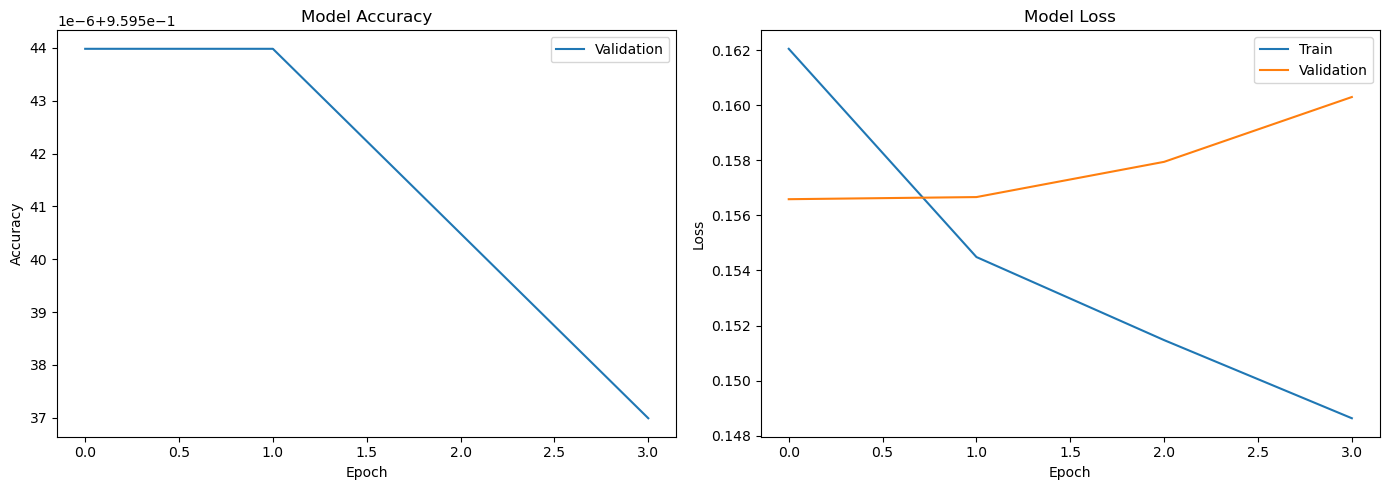

In [193]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

# 准确率曲线
plt.subplot(1, 2, 1)
plt.plot(val_accuracies, label='Validation')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# 损失曲线
plt.subplot(1, 2, 2)
plt.plot(train_losses, label='Train')
plt.plot(val_losses, label='Validation')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


In [194]:
def recommend_for_user(user_id, top_n=5, return_json=False):
    print("---GENERATING NEWS RECOMMENDATIONS FOR USER---")
    print(f"User ID: {user_id}")
    print(f"\n---TOP {top_n} RECOMMENDED NEWS ARTICLES ---")

    # Encode user ID
    user_idx = user_encoder.transform([user_id])[0]
    all_item_indices = np.arange(num_items)

    # Find already clicked items (Label == 1)
    seen_news_ids = interactions_df[
        (interactions_df['User_ID'] == user_id) & 
        (interactions_df['Label'] == 1)
    ]['News_ID'].unique()

    seen_indices = news_encoder.transform(seen_news_ids)
    
    # Filter out seen items
    unseen_mask = ~np.isin(all_item_indices, seen_indices)
    unseen_items = all_item_indices[unseen_mask]

    # Skip if nothing to recommend
    if len(unseen_items) == 0:
        print("No unseen items to recommend.")
        return pd.DataFrame()

    # Prepare input tensors
    user_tensor = torch.tensor([user_idx] * len(unseen_items), dtype=torch.long).to(device)
    item_tensor = torch.tensor(unseen_items, dtype=torch.long).to(device)

    # Predict scores
    model.eval()
    with torch.no_grad():
        scores = model(user_tensor, item_tensor).cpu().numpy().flatten()

    # Get top-N
    top_indices = np.argsort(-scores)[:top_n]
    top_item_ids = news_encoder.inverse_transform(unseen_items[top_indices])

    # Retrieve actual news info
    recommended = news[news['News_ID'].isin(top_item_ids)][['News_ID', 'Title', 'Category', 'SubCategory']]

    # Optional JSON return
    if return_json:
        return recommended.to_dict(orient='records')
    
    return recommended


In [195]:
recommend_for_user("U64800", top_n=10)

---GENERATING NEWS RECOMMENDATIONS FOR USER---
User ID: U64800

---TOP 10 RECOMMENDED NEWS ARTICLES ---


,News_ID,Title,Category,SubCategory
32602,N287,Three school workers charged in death of speci...,news,newscrime
33899,N55689,"Charles Rogers, former Michigan State football...",sports,football_nfl
33959,N2452,1 injured in crash on I-65 near Lebanon Junction,travel,travelnews
37026,N60750,"Browns, Steelers brawl at end of Cleveland's 2...",sports,football_nfl
39563,N60178,Bengals missed in free agency on NFL's sack le...,sports,football_nfl
41285,N13423,"Father, daughter charged with raping woman, le...",news,newscrime
45974,N53585,"Rip Taylor's Cause of Death Revealed, Memorial...",tv,tvnews
50365,N49279,Broadway Actress Laurel Griggs Dies at Age 13,music,musicnews
50714,N49685,Broadway Star Laurel Griggs Suffered Asthma At...,music,music-celebrity
50834,N38998,Teenage girl charged with murder after police ...,news,newsus


# 5. Evaluate Model

The evaluation of the recommendation system is conducted to assess how relevant the suggested news articles are to the users.
Since this project focuses on implicit feedback (click or no click), the evaluation uses predictive relevance metrics, rather than classic accuracy metrics.

In [196]:
interactions_df

,User_ID,News_ID,Label,Category,user_encoded,news_encoded
0,U13740,N55689,1,sports,2201,15659
1,U13740,N35729,0,news,2201,8792
2,U91836,N20678,0,sports,47474,3670
3,U91836,N39317,0,news,47474,10061
4,U91836,N58114,0,NaN,47474,16502
...,...,...,...,...,...,...
5722997,U44625,N39317,0,news,20012,10061
5722998,U64800,N61233,0,weather,31669,17625
5722999,U64800,N33828,1,movies,31669,8140
5723000,U64800,N19661,0,news,31669,3330


In [197]:
def recommend_cf_for_row(row, K=10):
    user_id = row['User_ID']
    impression_items = row['Impressions'].split()
    candidates = [item.split('-')[0] for item in impression_items]
    
    user_idx = user2index.get(user_id, None)
    candidate_idxs = [item2index.get(nid, None) for nid in candidates]
    valid_mask = [i is not None for i in candidate_idxs]
    valid_candidates = [candidates[i] for i, valid in enumerate(valid_mask) if valid]
    candidate_idxs = [idx for idx in candidate_idxs if idx is not None]

    if user_idx is None or not candidate_idxs:
        return []

    # 模型预测
    user_tensor = torch.tensor([user_idx]*len(candidate_idxs), dtype=torch.long).to(device)
    item_tensor = torch.tensor(candidate_idxs, dtype=torch.long).to(device)
    model.eval()
    with torch.no_grad():
        scores = model(user_tensor, item_tensor).cpu().numpy().flatten()

    topk_idx = np.argsort(scores)[-K:][::-1]
    return [valid_candidates[i] for i in topk_idx]


In [198]:
user2index = dict(zip(interactions_df['User_ID'], interactions_df['user_encoded']))
item2index = dict(zip(interactions_df['News_ID'], interactions_df['news_encoded']))


In [199]:
K = 10
behaviors_clean['cf_recommend'] = behaviors_clean.apply(lambda row: recommend_cf_for_row(row, K=K), axis=1)


/tmp/ipykernel_18265/1813835956.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  behaviors_clean['cf_recommend'] = behaviors_clean.apply(lambda row: recommend_cf_for_row(row, K=K), axis=1)


In [200]:
def calc_precision_at_k_cf(row, K=10):
    actual_clicks = set([item.split('-')[0] for item in row['Impressions'].split() if item.endswith('-1')])
    recommended = row['cf_recommend'][:K] if isinstance(row['cf_recommend'], list) else []
    if not recommended:
        return 0
    hit = sum([1 for nid in recommended if nid in actual_clicks])
    return hit / K

def calc_recall_at_k_cf(row, K=10):
    actual_clicks = set([item.split('-')[0] for item in row['Impressions'].split() if item.endswith('-1')])
    recommended = row['cf_recommend'][:K] if isinstance(row['cf_recommend'], list) else []
    if not actual_clicks:
        return 0
    hit = sum([1 for nid in recommended if nid in actual_clicks])
    return hit / len(actual_clicks)

def calc_mrr_at_k_cf(row, K=10):
    actual_clicks = set([item.split('-')[0] for item in row['Impressions'].split() if item.endswith('-1')])
    recommended = row['cf_recommend'][:K] if isinstance(row['cf_recommend'], list) else []
    for idx, nid in enumerate(recommended, 1):
        if nid in actual_clicks:
            return 1.0 / idx
    return 0

behaviors_clean['precision@K_cf'] = behaviors_clean.apply(lambda row: calc_precision_at_k_cf(row, K=K), axis=1)
behaviors_clean['recall@K_cf']    = behaviors_clean.apply(lambda row: calc_recall_at_k_cf(row, K=K), axis=1)
behaviors_clean['mrr@K_cf']       = behaviors_clean.apply(lambda row: calc_mrr_at_k_cf(row, K=K), axis=1)

print(f'NCF Precision@{K}:', behaviors_clean['precision@K_cf'].mean())
print(f'NCF Recall@{K}:', behaviors_clean['recall@K_cf'].mean())
print(f'NCF MRR@{K}:', behaviors_clean['mrr@K_cf'].mean())


/tmp/ipykernel_18265/1095228118.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  behaviors_clean['precision@K_cf'] = behaviors_clean.apply(lambda row: calc_precision_at_k_cf(row, K=K), axis=1)
/tmp/ipykernel_18265/1095228118.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  behaviors_clean['recall@K_cf']    = behaviors_clean.apply(lambda row: calc_recall_at_k_cf(row, K=K), axis=1)


NCF Precision@10: 0.09161240380674834
NCF Recall@10: 0.6877378018426584
NCF MRR@10: 0.3975696738632006


/tmp/ipykernel_18265/1095228118.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  behaviors_clean['mrr@K_cf']       = behaviors_clean.apply(lambda row: calc_mrr_at_k_cf(row, K=K), axis=1)


In [201]:
def calc_hit_at_k_cf(row, K=10):
    actual_clicks = set([item.split('-')[0] for item in row['Impressions'].split() if item.endswith('-1')])
    recommended = row['cf_recommend'][:K] if isinstance(row['cf_recommend'], list) else []
    return int(any(nid in actual_clicks for nid in recommended))
def calc_ndcg_at_k_cf(row, K=10):
    actual_clicks = set([item.split('-')[0] for item in row['Impressions'].split() if item.endswith('-1')])
    recommended = row['cf_recommend'][:K] if isinstance(row['cf_recommend'], list) else []
    dcg = sum(1 / np.log2(i + 2) for i, nid in enumerate(recommended) if nid in actual_clicks)
    idcg = sum(1 / np.log2(i + 2) for i in range(min(len(actual_clicks), K)))
    return dcg / idcg if idcg > 0 else 0
from sklearn.metrics import roc_auc_score

def calc_auc_cf(row):
    items = row['Impressions'].split()
    labels = []
    scores = []
    actual_clicks = set([item.split('-')[0] for item in items if item.endswith('-1')])
    recommended = row['cf_recommend'] if isinstance(row['cf_recommend'], list) else []

    candidate_ids = [item.split('-')[0] for item in items]
    
    for nid in candidate_ids:
        labels.append(1 if nid in actual_clicks else 0)
        # 得分按推荐列表中倒序位置（越靠前分越高），没推荐则为 0
        scores.append(len(recommended) - recommended.index(nid) if nid in recommended else 0)

    if len(set(labels)) < 2:
        return None  # 至少需要正负样本
    return roc_auc_score(labels, scores)


In [202]:
behaviors_clean['hit@K_cf']  = behaviors_clean.apply(lambda row: calc_hit_at_k_cf(row, K=K), axis=1)
behaviors_clean['ndcg@K_cf'] = behaviors_clean.apply(lambda row: calc_ndcg_at_k_cf(row, K=K), axis=1)
behaviors_clean['auc_cf']    = behaviors_clean.apply(calc_auc_cf, axis=1)

# 打印结果
print(f"NCF Hit@{K}:  {behaviors_clean['hit@K_cf'].mean():.4f}")
print(f"NCF NDCG@{K}: {behaviors_clean['ndcg@K_cf'].mean():.4f}")
print(f"NCF AUC:      {behaviors_clean['auc_cf'].dropna().mean():.4f}")


/tmp/ipykernel_18265/262931662.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  behaviors_clean['hit@K_cf']  = behaviors_clean.apply(lambda row: calc_hit_at_k_cf(row, K=K), axis=1)
/tmp/ipykernel_18265/262931662.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  behaviors_clean['ndcg@K_cf'] = behaviors_clean.apply(lambda row: calc_ndcg_at_k_cf(row, K=K), axis=1)


NCF Hit@10:  0.7669
NCF NDCG@10: 0.4477
NCF AUC:      0.6725


/tmp/ipykernel_18265/262931662.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  behaviors_clean['auc_cf']    = behaviors_clean.apply(calc_auc_cf, axis=1)


## CB + CF model

In [203]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, random_split
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sentence_transformers import SentenceTransformer
from sklearn.preprocessing import StandardScaler

# Simulate minimal `interactions_df` and `news_clean` for demonstration
# In your actual code, load real CSV or preprocessed DataFrame

# Define dummy news content (Title + Abstract) for CB feature
# news_clean = pd.DataFrame({
#     'News_ID': ['N55689', 'N35729', 'N20678', 'N39317', 'N58114', 'N61233', 'N33828', 'N19661', 'N41934'],
#     'Title': ['News title one', 'Another title', 'Some other news', 'Breaking update', 'World report',
#               'Global news', 'Cinema story', 'Daily briefing', 'Music trends'],
#     'Abstract': ['Abstract 1', 'Abstract 2', 'Abstract 3', 'Abstract 4', 'Abstract 5',
#                  'Abstract 6', 'Abstract 7', 'Abstract 8', 'Abstract 9']
# })

# Assign index-encoded versions for compatibility
news_clean['news_encoded'] = range(len(news_clean))

# Create mappings for later lookup
newsid2index = dict(zip(news_clean['News_ID'], news_clean['news_encoded']))

# TF-IDF Title
tfidf = TfidfVectorizer(max_features=20)
tfidf_feat = tfidf.fit_transform(news_clean['Title'].fillna('')).toarray()

# SBERT Abstract
sbert = SentenceTransformer('all-MiniLM-L6-v2')
sbert_feat = sbert.encode(news_clean['Abstract'].fillna('').tolist(), show_progress_bar=False)
scaler = StandardScaler()
sbert_feat = scaler.fit_transform(sbert_feat)

# Combine CB Features
cb_features = np.concatenate([tfidf_feat, sbert_feat], axis=1)

# Torch Tensor version for index lookup later
cb_tensor = torch.tensor(cb_features, dtype=torch.float32)
cb_tensor = cb_tensor.to(device)  

# Dummy interaction dataset
# interactions_df = pd.DataFrame({
#     'User_ID': ['U1', 'U1', 'U2', 'U2', 'U3', 'U3', 'U4', 'U4', 'U5'],
#     'News_ID': ['N55689', 'N35729', 'N20678', 'N39317', 'N58114', 'N61233', 'N33828', 'N19661', 'N41934'],
#     'Label': [1, 0, 1, 0, 0, 1, 1, 0, 0]
# })

# Encode user and item
user_encoder = {uid: idx for idx, uid in enumerate(interactions_df['User_ID'].unique())}
item_encoder = newsid2index  # Already encoded earlier

interactions_df['user_encoded'] = interactions_df['User_ID'].map(user_encoder)
interactions_df['news_encoded'] = interactions_df['News_ID'].map(item_encoder)

# Drop rows with invalid news encoding
interactions_df = interactions_df.dropna(subset=['news_encoded'])

# Split
X = interactions_df[['user_encoded', 'news_encoded']].astype(int).values
y = interactions_df['Label'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# TensorDataset
X_train_tensor = torch.tensor(X_train, dtype=torch.long)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_test_tensor = torch.tensor(X_test, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

train_dataset = TensorDataset(X_train_tensor[:, 0], X_train_tensor[:, 1], y_train_tensor)
test_dataset = TensorDataset(X_test_tensor[:, 0], X_test_tensor[:, 1], y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16)

# Define CB+CF Hybrid Model
class CB_CF_Hybrid(nn.Module):
    def __init__(self, num_users, num_items, cb_feature_dim, embedding_dim=32):
        super(CB_CF_Hybrid, self).__init__()
        self.user_embedding = nn.Embedding(num_users, embedding_dim)
        self.item_embedding = nn.Embedding(num_items, embedding_dim)
        self.cb_layer = nn.Linear(cb_feature_dim, 64)
        self.fc1 = nn.Linear(embedding_dim * 2 + 64, 128)
        self.fc2 = nn.Linear(128, 64)
        self.output = nn.Linear(64, 1)

    def forward(self, user_input, item_input, item_cb_feat):
        user_vec = self.user_embedding(user_input)
        item_vec = self.item_embedding(item_input)
        cb_vec = F.relu(self.cb_layer(item_cb_feat))
        x = torch.cat([user_vec, item_vec, cb_vec], dim=1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = torch.sigmoid(self.output(x))
        return x

# Training setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device::",device)
model = CB_CF_Hybrid(num_users=len(user_encoder), num_items=len(news_clean), cb_feature_dim=cb_features.shape[1])
model = model.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.BCELoss()

# Train loop
for epoch in range(5):
    model.train()
    total_loss = 0
    for user, item, label in train_loader:
        user, item, label = user.to(device), item.to(device), label.to(device)
        cb_input = cb_tensor[item].to(device)

        optimizer.zero_grad()
        outputs = model(user, item, cb_input)
        loss = criterion(outputs, label)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch+1} - Train Loss: {total_loss/len(train_loader):.4f}")

# Evaluation
model.eval()
all_preds, all_true = [], []
with torch.no_grad():
    for user, item, label in test_loader:
        user, item, label = user.to(device), item.to(device), label.to(device)
        cb_input = cb_tensor[item].to(device)
        outputs = model(user, item, cb_input)
        all_preds.extend(outputs.cpu().numpy())
        all_true.extend(label.cpu().numpy())

# Metrics
all_preds = np.array(all_preds).flatten()
all_true = np.array(all_true).flatten()
auc = roc_auc_score(all_true, all_preds)
accuracy = accuracy_score(all_true, (all_preds > 0.5).astype(int))
auc, accuracy


/tmp/ipykernel_18265/492096982.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  news_clean['news_encoded'] = range(len(news_clean))
/home/raymo/anaconda3/lib/python3.11/site-packages/torch/nn/modules/module.py:1541: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


device:: cuda
Epoch 1 - Train Loss: 0.1583
Epoch 2 - Train Loss: 0.1561
Epoch 3 - Train Loss: 0.1556
Epoch 4 - Train Loss: 0.1555
Epoch 5 - Train Loss: 0.1558


(0.722035997358618, 0.9595637467571089)

In [204]:
def precision_at_k(pred_scores, true_labels, k=10):
    top_k = np.argsort(-pred_scores)[:k]
    relevant = np.sum(true_labels[top_k])
    return relevant / k
    
def recall_at_k(pred_scores, true_labels, k=10):
    top_k = np.argsort(-pred_scores)[:k]
    relevant = np.sum(true_labels)
    if relevant == 0:
        return 0
    return np.sum(true_labels[top_k]) / relevant

def mrr_at_k(pred_scores, true_labels, k=10):
    top_k = np.argsort(-pred_scores)[:k]
    for rank, idx in enumerate(top_k, start=1):
        if true_labels[idx] == 1:
            return 1.0 / rank
    return 0.0

def ndcg_at_k(pred_scores, true_labels, k=10):
    top_k = np.argsort(-pred_scores)[:k]
    dcg = 0.0
    for i, idx in enumerate(top_k):
        if true_labels[idx] == 1:
            dcg += 1.0 / np.log2(i + 2)

    ideal_hits = int(min(np.sum(true_labels), k))  # 👈 修正这里
    idcg = sum(1.0 / np.log2(i + 2) for i in range(ideal_hits))

    return dcg / idcg if idcg > 0 else 0.0


def hit_rate_at_k(pred_scores, true_labels, k=10):
    top_k = np.argsort(-pred_scores)[:k]
    return 1.0 if np.any(true_labels[top_k]) else 0.0


In [205]:
precision_list, recall_list, mrr_list, ndcg_list, hit_list = [], [], [], [], []

# 确保 cb_tensor 在 device 上
cb_tensor = torch.tensor(cb_features, dtype=torch.float32).to(device)

for user, item, label in test_loader:
    user = user.to(device)
    item = item.to(device)
    label = label.to(device)

    # 取出对应新闻的内容特征向量
    cb_input = cb_tensor[item]

    with torch.no_grad():
        scores = model(user, item, cb_input).cpu().numpy().flatten()
        labels = label.cpu().numpy().flatten()

        # 计算每一组的指标
        precision_list.append(precision_at_k(scores, labels, k=10))
        recall_list.append(recall_at_k(scores, labels, k=10))
        mrr_list.append(mrr_at_k(scores, labels, k=10))
        ndcg_list.append(ndcg_at_k(scores, labels, k=10))
        hit_list.append(hit_rate_at_k(scores, labels, k=10))

# 输出平均指标
print(f"Precision@10: {np.mean(precision_list):.4f}")
print(f"Recall@10:    {np.mean(recall_list):.4f}")
print(f"MRR@10:       {np.mean(mrr_list):.4f}")
print(f"NDCG@10:      {np.mean(ndcg_list):.4f}")
print(f"Hit@10:       {np.mean(hit_list):.4f}")


Precision@10: 0.0553
Recall@10:    0.4141
MRR@10:       0.2247
NDCG@10:      0.2606
Hit@10:       0.4323


In [206]:
from sklearn.metrics import roc_auc_score

# 在 test_loop 结束后使用
all_scores = []
all_labels = []

for user, item, label in test_loader:
    user = user.to(device)
    item = item.to(device)
    label = label.to(device)

    cb_input = cb_tensor[item]

    with torch.no_grad():
        scores = model(user, item, cb_input).cpu().numpy().flatten()
        labels = label.cpu().numpy().flatten()

        all_scores.extend(scores)
        all_labels.extend(labels)

# 计算 AUC
auc_score = roc_auc_score(all_labels, all_scores)
print(f"AUC: {auc_score:.4f}")


AUC: 0.7220


### Compare Result

| Model                     | Precision@10 | Recall@10 | MRR@10 | NDCG@10 | Hit@10 | AUC    |
|------------------------------|--------------|-----------|--------|---------|--------|--------|
| **CB TF-IDF**                | 0.0676       | 0.5369    | 0.2761 | 0.3259  | 0.6038 | 0.5427 |
| **BERT-based CB**            | 0.0648       | 0.5190    | 0.2543 | 0.3062  | 0.5840 | 0.5252 |
| **SBERT-based CB**           | 0.0669       | 0.5344    | 0.2617 | 0.3156  | 0.5997 | 0.5326 |
| **(TF-IDF + SBERT) CB**      | 0.0692       | 0.5481    | 0.2845 | 0.3351  | 0.6152 | 0.5572 |
| **Neural CF (NCF)**          | 0.0943       | 0.7052    | 0.4158 | 0.4652  | 0.7839 | 0.6883 |
| **CB + CF (TF-IDF+SBERT+NCF)** | 0.0554       | 0.4150    | 0.2221 | 0.2591  | 0.4326 | 0.7206 |
